# **Classification Model Training Notebook**



---
## Setup Environment

In [1]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT3",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 91.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Mounted at /content/gdrive

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT3/data


---
## Student Information

In [2]:
group_name = ""
student_name = "Yi An Tsai"
student_id = "25532767"

In [3]:
# Do not modify this code
print_tile(size="h1", key='group_name', value=group_name)

In [4]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [5]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [6]:
# <Student to fill this section>

### 0.b Import Packages

In [7]:
import pandas as pd
import altair as alt
import seaborn as sns
import matplotlib.pyplot as plt

---
## B. Business Understanding

In [8]:
business_use_case_description = """
This project aims to increase revenue through identify each customer's favorite product category based on their purchase history,
in order to enable more targeted and effective advertising campaigns.
By understanding consumer preferences,
businesses can promote the right products to the right customers,
reducing wasted advertising spend and improving customer engagement.

"""

In [9]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [10]:
business_objectives = """
Given the result of baseline model and the business usecase,
a successful projoct should achieve the following:
1. accuracy of validation > 0.8
2. F1-score of validation > 0.7

When this project successfully achieves its goal,
each customer will be targeted with an appropriate promotion strategy,
advertising their preferred product categories to the correct segments.
This will boost purchase intent and directly contribute to increased company revenue.

However, if this project fails to achieve its goal,
advertisements will not reach the intended target segments and boost any consuming desire,
and customers will not receive promotions for their preferred items.
This will not only negatively impact revenue,
but also waste advertising budget and result in unnecessary business losses.
"""

In [11]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [12]:
stakeholders_expectations_explanations = """
Upon project completion, a prediction model identifying each customer's favorite product category will be available for use.
The results will be used to serve as a reference for the sales department to develop effective marketing strategies.

Multiple departments are stakeholders of this project:

The sales department will use the results to design targeted advertisements for each customer segment.
The product department will use the insights to ensure sufficient stock levels ahead of upcoming promotions.
The operations department will be responsible for ensuring smooth delivery, logistics,
and payment processing for anticipated orders.

Beyond these departments, both the company and its customers will be impacted by the predictions.
Accurate predictions will increase company revenue and enhance the customer experience,
while inaccurate predictions may result in missed opportunities and reduced customer engagement.
"""

In [13]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [14]:
try:
  X_train = pd.read_csv(at.folder_path / 'X_train.csv')
  X_val = pd.read_csv(at.folder_path / 'X_val.csv')
  X_test = pd.read_csv(at.folder_path / 'X_test.csv')

except Exception as e:
  print(e)

### C.2 Define Target variable

In [15]:
target_definition_explanations = """
From eacu customer's purchase history, the most frequently purchased purchase items is identifiedt, defined as the customer's favorite category,
as well as target variable.

Each customer's purchase history is grouped by category to count the purchase frequency per category.
In cases where two or more categories have the same purchase count (tie),
the category with the higher total spending is selected as the customer's favorite category.
"""

In [16]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [17]:
target_name = 'preffered_category'   # the most frequent item for each customer

In [18]:
X_train.head()

,sales_order_id,sales_order_detail_id,order_quantity,special_offer_id,unit_price,unit_price_discount,line_total,category_name,online_order_flag,customer_id,order_date,sub_total,tax_amount,freight,total_due,sales_country,sales_group,customer_country,customer_group
0,0fbc9d71-4176-4c77-92c6-d7ede2a9ce33,354.0,1.0,a1444fcd-4b51-4227-94cf-b13c1a2a6281,3399.99,0.0,3399.99,Bikes,1.0,533ca1cb-2726-48d0-93c1-42721f59e970,2011-05-30 22:00:00,3399.99,271.9992,84.9998,3756.9890,France,Europe,France,Europe
1,18609f9d-aedc-4665-bbc8-5d7a99599915,357.0,1.0,a1444fcd-4b51-4227-94cf-b13c1a2a6281,3399.99,0.0,3399.99,Bikes,1.0,76203fe8-fab7-451c-9cc4-9e4132767500,2011-05-30 22:00:00,3399.99,271.9992,84.9998,3756.9890,Australia,Pacific,Australia,Pacific
2,0570389a-6bfa-45c2-85a4-36784fa7b5b1,359.0,1.0,a1444fcd-4b51-4227-94cf-b13c1a2a6281,3578.27,0.0,3578.27,Bikes,1.0,78a9fd83-9f02-4327-8583-6828109df730,2011-05-31 22:00:00,3578.27,286.2616,89.4568,3953.9884,Australia,Pacific,Australia,Pacific
3,b48cdf2f-270a-41d0-9cde-36616fecd302,360.0,1.0,a1444fcd-4b51-4227-94cf-b13c1a2a6281,3374.99,0.0,3374.99,Bikes,1.0,c99aa983-6460-404b-8ab3-43221631428f,2011-05-31 22:00:00,3374.99,269.9992,84.3748,3729.3640,Australia,Pacific,Australia,Pacific
4,03533644-6a12-499b-9726-aaa1088c56a5,361.0,1.0,a1444fcd-4b51-4227-94cf-b13c1a2a6281,3399.99,0.0,3399.99,Bikes,1.0,de1e6e53-779e-4881-a108-0f97621c6259,2011-05-31 22:00:00,3399.99,271.9992,84.9998,3756.9890,Australia,Pacific,Australia,Pacific


In [19]:
def create_target_variable(dataset):
    """
    Create a target variable for the provided dataset.
    workflow:
    1. count the frequency
    2. select the maximum count_rows (of each customer) as a variable
    3. return it to dataset
    4. keep the first row of each customer, drop other rows
    5. keep customer behavior features
    6. check no explode
    7. hava look of new dataset

    """

    original_dataset_shape = dataset.shape

    # count the frequency
    customer_category = dataset.groupby(['customer_id', 'category_name']).agg(
    count_rows = ('category_name', 'size'),  # Create a feature for category_name frequency
    total_spent = ('line_total', 'sum')            # sum the line_total
).reset_index()

    # select the maximum count_rows (of each customer)
    top_category = (
    customer_category
    .sort_values(
        ['customer_id', 'count_rows', 'total_spent'],  # sort with total_spent, prevent from one rows with two same count_rows
        ascending=[True, False, False]
    )
    .drop_duplicates(subset='customer_id', keep='first')
)

    # assign a new name
    top_category = top_category.rename(columns={'category_name': 'preffered_category'})

    # ensure unique row count equals total row count  (no duplicates)
    print(f'Unique customers in training_df: {dataset["customer_id"].nunique()}')
    print(f'Rows in top_category: {len(top_category)}')

    # have a look
    top_category.head()

    # put 'preffered_category' into X_train
    dataset = dataset.merge(
        top_category[['customer_id', 'preffered_category']],
        on='customer_id',
        how='left'
    )


    print(f'The original dataset with shape:{original_dataset_shape}')
    print(f'The dataset after creating target_variable with shape:{dataset.shape} ')


    # Keep the customer behavior columns
    dataset = dataset[[
        'customer_id',
        'order_date',
        'online_order_flag',
        'total_due',
        'sales_order_id',
        'special_offer_id',
        'order_quantity',
        'sales_country',
        'sales_group',
        'customer_country',
        'customer_group',
        # 'spending_change_pct',
        # 'spending_group',
        # 'avg_items_per_order',
        # 'avg_order_amount',
        'preffered_category'
        ]]

    # # keep the first row of each customer, drop other rows
    # dataset = dataset.groupby('customer_id').first().reset_index()

    return dataset

In [20]:
X_train = create_target_variable(X_train)

Unique customers in training_df: 6674
Rows in top_category: 6674
The original dataset with shape:(24750, 19)
The dataset after creating target_variable with shape:(24750, 20) 


In [21]:
# apply on val set
X_val = create_target_variable(X_val)

Unique customers in training_df: 2876
Rows in top_category: 2876
The original dataset with shape:(8837, 19)
The dataset after creating target_variable with shape:(8837, 20) 


In [22]:
# on test set
X_test = create_target_variable(X_test)

Unique customers in training_df: 2749
Rows in top_category: 2749
The original dataset with shape:(8513, 19)
The dataset after creating target_variable with shape:(8513, 20) 


In [23]:
X_train.head()

,customer_id,order_date,online_order_flag,total_due,sales_order_id,special_offer_id,order_quantity,sales_country,sales_group,customer_country,customer_group,preffered_category
0,533ca1cb-2726-48d0-93c1-42721f59e970,2011-05-30 22:00:00,1.0,3756.9890,0fbc9d71-4176-4c77-92c6-d7ede2a9ce33,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,France,Europe,France,Europe,Bikes
1,76203fe8-fab7-451c-9cc4-9e4132767500,2011-05-30 22:00:00,1.0,3756.9890,18609f9d-aedc-4665-bbc8-5d7a99599915,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,Australia,Pacific,Australia,Pacific,Accessories
2,78a9fd83-9f02-4327-8583-6828109df730,2011-05-31 22:00:00,1.0,3953.9884,0570389a-6bfa-45c2-85a4-36784fa7b5b1,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,Australia,Pacific,Australia,Pacific,Bikes
3,c99aa983-6460-404b-8ab3-43221631428f,2011-05-31 22:00:00,1.0,3729.3640,b48cdf2f-270a-41d0-9cde-36616fecd302,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,Australia,Pacific,Australia,Pacific,Bikes
4,de1e6e53-779e-4881-a108-0f97621c6259,2011-05-31 22:00:00,1.0,3756.9890,03533644-6a12-499b-9726-aaa1088c56a5,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,Australia,Pacific,Australia,Pacific,Bikes


In [24]:
X_val.head()

,customer_id,order_date,online_order_flag,total_due,sales_order_id,special_offer_id,order_quantity,sales_country,sales_group,customer_country,customer_group,preffered_category
0,c7eac053-3157-4da1-b4ee-906d02b22d61,2013-12-30 23:00:00,0.0,2298.3776,56bef9d7-dc16-4edd-b1d9-a242cfeb08c3,a1444fcd-4b51-4227-94cf-b13c1a2a6281,2.0,United Kingdom,Europe,United Kingdom,Europe,Bikes
1,bac865db-cb34-41a4-b52a-eaaf8ad7d794,2013-12-30 23:00:00,0.0,1690.8077,9cceff64-759c-4c68-8235-1a19c3333a8f,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,France,Europe,France,Europe,Clothing
2,bac865db-cb34-41a4-b52a-eaaf8ad7d794,2013-12-30 23:00:00,0.0,1690.8077,9cceff64-759c-4c68-8235-1a19c3333a8f,a1444fcd-4b51-4227-94cf-b13c1a2a6281,2.0,France,Europe,France,Europe,Clothing
3,bac865db-cb34-41a4-b52a-eaaf8ad7d794,2013-12-30 23:00:00,0.0,1690.8077,9cceff64-759c-4c68-8235-1a19c3333a8f,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,France,Europe,France,Europe,Clothing
4,c3b38117-cc11-48ae-a713-6390fff6a2c8,2013-12-30 23:00:00,0.0,13575.9101,54ac3409-a26c-40f6-8147-90ac00c9be1f,a1444fcd-4b51-4227-94cf-b13c1a2a6281,2.0,Australia,Pacific,Australia,Pacific,Bikes


In [25]:
X_test.head()

,customer_id,order_date,online_order_flag,total_due,sales_order_id,special_offer_id,order_quantity,sales_country,sales_group,customer_country,customer_group,preffered_category
0,6ae95aa4-2f6c-4821-9b5c-b7c2bdf25f1f,2014-03-27 23:00:00,1.0,27.6140,5be0c23b-866d-46f0-ac9c-83cb336660ee,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,Australia,Pacific,Australia,Pacific,Accessories
1,15bf275b-1350-4295-b76b-5cb5fa0bda1b,2014-03-27 23:00:00,1.0,97.7483,99a9f6d7-a400-4b3d-bdff-bdaa707bc389,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,Australia,Pacific,Australia,Pacific,Accessories
2,15bf275b-1350-4295-b76b-5cb5fa0bda1b,2014-03-27 23:00:00,1.0,97.7483,99a9f6d7-a400-4b3d-bdff-bdaa707bc389,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,Australia,Pacific,Australia,Pacific,Accessories
3,15bf275b-1350-4295-b76b-5cb5fa0bda1b,2014-03-27 23:00:00,1.0,97.7483,99a9f6d7-a400-4b3d-bdff-bdaa707bc389,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,Australia,Pacific,Australia,Pacific,Accessories
4,15bf275b-1350-4295-b76b-5cb5fa0bda1b,2014-03-27 23:00:00,1.0,97.7483,99a9f6d7-a400-4b3d-bdff-bdaa707bc389,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,Australia,Pacific,Australia,Pacific,Accessories


In [26]:
# check it is unique customer id of each row (no duplicate)
print(f'The rows of training set is: {X_train.shape}')
print(f'The unique customer_id of training set is: {X_train['customer_id'].nunique()}')

The rows of training set is: (24750, 12)
The unique customer_id of training set is: 6674


In [27]:
# check on val and test sets
print(f'The rows of validation set is: {X_val.shape}')
print(f'The unique customer_id of validation set is: {X_val['customer_id'].nunique()}', '\n', '-'*30)

print(f'The rows of test set is: {X_test.shape}')
print(f'The unique customer_id of test set is: {X_test['customer_id'].nunique()}')


The rows of validation set is: (8837, 12)
The unique customer_id of validation set is: 2876 
 ------------------------------
The rows of test set is: (8513, 12)
The unique customer_id of test set is: 2749


In [28]:
# check if all columns are the same in each dataset

for col in X_train.columns:
    if col not in X_val.columns:
        print(f"{col} is not in X_val")
    if col not in X_test.columns:
        print(f"{col} is not in X_test")
    else:
        print('all same')

all same
all same
all same
all same
all same
all same
all same
all same
all same
all same
all same
all same


### C.4 Explore Target variable

Due to the same total_due of each same sales_order_id, only first sales_order_id leave to prevent from duplicate count.

In [29]:
# for customer-level exploration
customer_level = X_train.drop_duplicates(subset='customer_id')

# the customer number of each category
customer_level ['preffered_category'].value_counts(normalize='index')

,proportion
preffered_category,
Bikes,0.525472
Accessories,0.394816
Clothing,0.072820
Components,0.006892


In [30]:
pd.crosstab(customer_level ['preffered_category'], customer_level ['sales_country'], normalize='index')

sales_country,Australia,France,Germany,United Kingdom
preffered_category,,,,
Accessories,0.361670,0.199620,0.199241,0.239469
Bikes,0.516396,0.147134,0.158540,0.177930
Clothing,0.409465,0.230453,0.158436,0.201646
Components,0.217391,0.304348,0.217391,0.260870


To calculate the mean or average total, it is best to based on order_level.

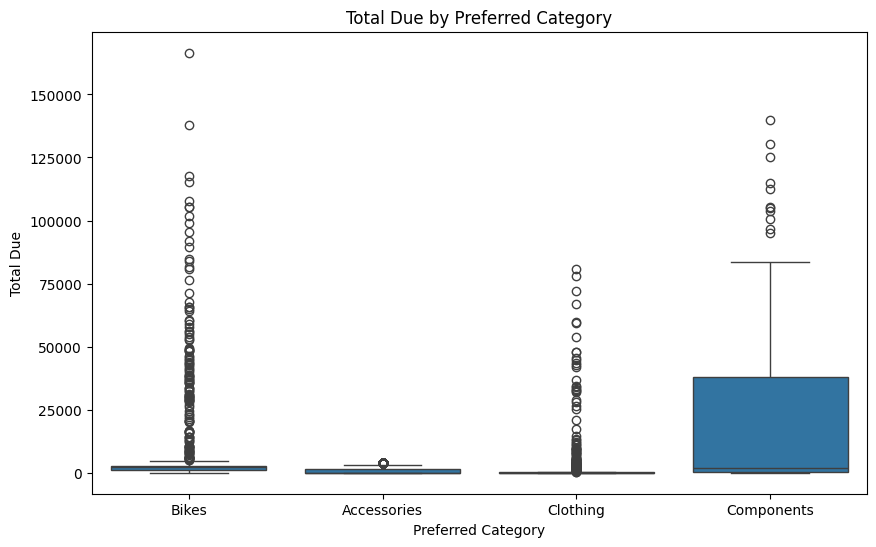

In [31]:
# for order-level exploration
order_level = X_train.drop_duplicates(subset='sales_order_id')

plt.figure(figsize=(10, 6))
sns.boxplot(x='preffered_category', y='total_due', data=order_level)
plt.title('Total Due by Preferred Category')
plt.xlabel('Preferred Category')
plt.ylabel('Total Due')
plt.show()

In [32]:
target_distribution_explanations = """
This datasets shows extremely imbalance classess,which might cause difficult for model to learning.

The proportion of components merely 0.6% of entire dataset, with the highest, wide range of total due distribution,
proving that the customer hehavrior exactly has different between those segments.
"""

In [33]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `Total_due`

In [34]:
# the avg total due of each category.
order_level.groupby('preffered_category')['total_due'].mean()

,total_due
preffered_category,
Accessories,808.109530
Bikes,3170.862951
Clothing,2698.195878
Components,22399.913002


In [35]:
feature_1_insights = """
the customer with different preffered category has different average order amount,
the lowest is accessories (808) and the highest is components(22399),
which might help model to capture the difference in purchasing behavior.

"""

In [36]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `order_quantity`

In [37]:
X_train.head()

,customer_id,order_date,online_order_flag,total_due,sales_order_id,special_offer_id,order_quantity,sales_country,sales_group,customer_country,customer_group,preffered_category
0,533ca1cb-2726-48d0-93c1-42721f59e970,2011-05-30 22:00:00,1.0,3756.9890,0fbc9d71-4176-4c77-92c6-d7ede2a9ce33,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,France,Europe,France,Europe,Bikes
1,76203fe8-fab7-451c-9cc4-9e4132767500,2011-05-30 22:00:00,1.0,3756.9890,18609f9d-aedc-4665-bbc8-5d7a99599915,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,Australia,Pacific,Australia,Pacific,Accessories
2,78a9fd83-9f02-4327-8583-6828109df730,2011-05-31 22:00:00,1.0,3953.9884,0570389a-6bfa-45c2-85a4-36784fa7b5b1,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,Australia,Pacific,Australia,Pacific,Bikes
3,c99aa983-6460-404b-8ab3-43221631428f,2011-05-31 22:00:00,1.0,3729.3640,b48cdf2f-270a-41d0-9cde-36616fecd302,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,Australia,Pacific,Australia,Pacific,Bikes
4,de1e6e53-779e-4881-a108-0f97621c6259,2011-05-31 22:00:00,1.0,3756.9890,03533644-6a12-499b-9726-aaa1088c56a5,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,Australia,Pacific,Australia,Pacific,Bikes


In [38]:
order_level['sum_quantity'] = order_level.groupby('sales_order_id')['order_quantity'].transform('sum')
order_level['avg_quantity'] = order_level['sum_quantity'] / order_level.groupby('sales_order_id')['order_quantity'].transform('count')

In [39]:
order_level.groupby(['preffered_category'])['avg_quantity'].mean()

,avg_quantity
preffered_category,
Accessories,1.000291
Bikes,1.049273
Clothing,1.367622
Components,2.325397


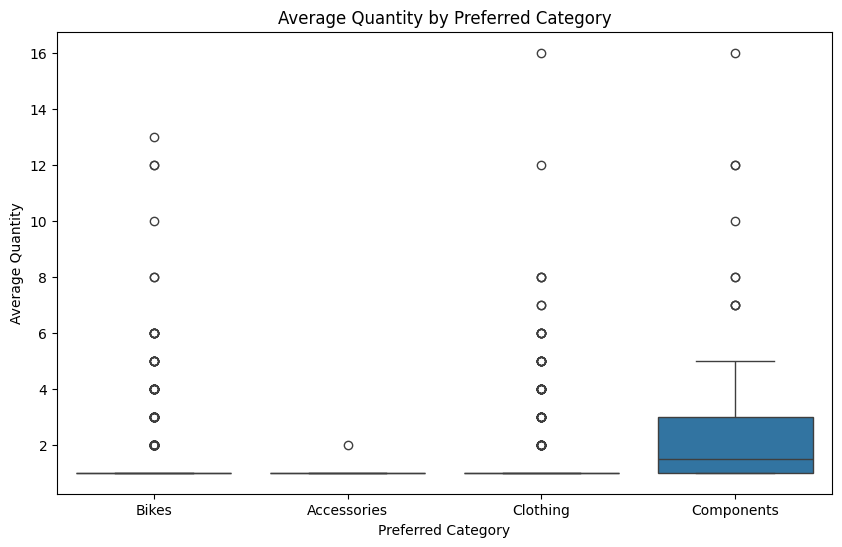

In [40]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='preffered_category', y='avg_quantity', data=order_level)
plt.title('Average Quantity by Preferred Category')
plt.xlabel('Preferred Category')
plt.ylabel('Average Quantity')
plt.show()

In [41]:
feature_2_insights = """

While exploring the order_quantity, we find that the components segment has most order_quantity,
other three categories with nearly 1 quantity.
This finding shows that components customers have a distinctly different purchasing pattern compared to the other three categories.

"""

In [42]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.7 Explore Feature of Interest `online_order_flag`


In [43]:
customer_level['online_order_flag'].value_counts()

,count
online_order_flag,
1.0,6538
0.0,136


In [44]:
pd.crosstab(customer_level['online_order_flag'], customer_level['preffered_category'])

preffered_category,Accessories,Bikes,Clothing,Components
online_order_flag,,,,
0.0,1,65,24,46
1.0,2634,3442,462,0


In [45]:
pd.crosstab(order_level['online_order_flag'], order_level['preffered_category'])

preffered_category,Accessories,Bikes,Clothing,Components
online_order_flag,,,,
0.0,1,198,91,126
1.0,3437,5099,502,0


In [46]:
pd.crosstab(X_train['online_order_flag'], X_train['preffered_category'])

preffered_category,Accessories,Bikes,Clothing,Components
online_order_flag,,,,
0.0,1,3782,1727,1867
1.0,8727,7666,980,0


In [47]:
feature_3_insights = """
Looking at the crosstab, all Components customers place exclusively offline orders,
while the other three categories show a mix of online and offline orders.
This distinct pattern makes online_order_flag a strong indicator for identifying the Components segment,
which can help the model capture this minority class more effectively.
"""

In [48]:
# Do not modify this code
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

---
## D. Feature Selection


In [50]:
features_list = ['customer_id', 'order_date', 'total_due', 'sales_order_id',
       'special_offer_id', 'order_quantity', 'sales_country', 'sales_group',
       'customer_country', 'customer_group', 'preffered_category']

In [149]:
feature_selection_explanations = """
For the future feature engineering, customer_id, order_date, sales_order_id are kept due to it representing the unique information of each order.
As for other features, such as sales_country, sales_group and customer_country, those are information of customers themself, might be useful for model training.

"""

In [150]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation 'order_date'

In [53]:
X_train['order_date'] = pd.to_datetime(X_train['order_date'])
X_val['order_date'] = pd.to_datetime(X_val['order_date'])
X_test['order_date'] = pd.to_datetime(X_test['order_date'])

print("Order date columns converted to datetime format.")

Order date columns converted to datetime format.


In [54]:
data_cleaning_1_explanations = """
Convert 'order_date' to datetime format for easier manipulation and analysis.
"""

In [55]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

---
## F. Feature Engineering

### F.1 New Feature "spending_change"


In [56]:
# cus_id level
g = X_train.groupby('customer_id')

max_idx = g['order_date'].idxmax()     # row index of lastest
min_idx = g['order_date'].idxmin()      #  row index of earliest order per customer

# return the resutlt
result = pd.concat([    # combine max and min_idx
    X_train.loc[max_idx].assign(type='max'),      # assign =>  create new columns, name ='type', value=max
    X_train.loc[min_idx].assign(type='min')
]).sort_values(['customer_id', 'type'])


"\n df.loc[ conditions ]\n\ne.g.\ndf.loc[df['age'] > 20]   =>  rows where age > 20\ndf.loc[5]  => rows where index = 5\ndf.loc[[3,5,7]]   => rows where index = 3,5,7\n"

In [152]:
# select max result of every combination of customer_id and total_due
max_df = result[result['type'] == 'max'][['customer_id', 'total_due']]
max_df = max_df.rename(columns={'total_due': 'max_due'})                 # rename

min_df = result[result['type'] == 'min'][['customer_id', 'total_due']]
min_df = min_df.rename(columns={'total_due': 'min_due'})

# merge min and max table, compute "spending_charge_pct"
spending = max_df.merge(min_df, on='customer_id')
spending['spending_change_pct'] = (spending['max_due'] - spending['min_due']) / spending['min_due'] * 100

# select columns, merge with X_train
selected_spending = ['customer_id', 'spending_change_pct']
X_train = X_train.merge(spending[selected_spending], on= 'customer_id', how='left'  )

IndentationError: unexpected indent (3705310825.py, line 3)

In [58]:
X_train['spending_change_pct'].describe()

,spending_change_pct
count,24750.000000
mean,37.938655
std,452.495738
min,-98.387065
25%,-34.745840
50%,0.000000
75%,0.000000
max,4987.415439


In [59]:
# applied on two datasets

X_val = X_val.merge(
    spending[['customer_id', 'spending_change_pct']],
    on='customer_id',
    how='left'
)

X_test = X_test.merge(
    spending[['customer_id', 'spending_change_pct']],
    on='customer_id',
    how='left'
)

In [60]:
# deal with Nan

# counts of nan
print(f'The Nan in this new feature of val set: {X_val['spending_change_pct'].isnull().sum()}')
print(f'The total columns of val set: {X_val['spending_change_pct'].isnull().sum()}')
print('-'*30)
print(f'The Nan in this new feature of test set: {X_test['spending_change_pct'].isnull().sum()}')
print(f'The total columns of test set: {X_test['spending_change_pct'].isnull().sum()}')

# fill nan with 0
X_val['spending_change_pct'] = X_val['spending_change_pct'].fillna(0)
X_test['spending_change_pct'] = X_test['spending_change_pct'].fillna(0)

# check again
print('-'*30,'\n After fillna')
print(f'The Nan in this new feature of val set: {X_val['spending_change_pct'].isnull().sum()}')
print(f'The Nan in this new feature of test set: {X_test['spending_change_pct'].isnull().sum()}')

The Nan in this new feature of val set: 3310
The total columns of val set: 3310
------------------------------
The Nan in this new feature of test set: 3322
The total columns of test set: 3322
------------------------------ 
 After fillna
The Nan in this new feature of val set: 0
The Nan in this new feature of test set: 0


In [61]:
feature_engineering_1_explanations = """
Provide some explanations on why you believe it is important to create this feature and its impacts
To assess customer behavrior pattern, recording their buying amount shifts is an objective method.
But no feature directly represents this meaning, so spending_change_pct is created here.
"""

In [62]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature "spending_level"




In [63]:
# at order level
order_level_df = X_train.drop_duplicates(subset='sales_order_id')
order_level_df['total_due'].describe()

,total_due
count,9454.000000
mean,2538.265370
std,7918.912184
min,2.530500
25%,94.455400
50%,1381.073200
75%,2673.061300
max,166537.080800


In [64]:
# threshold
q25 = order_level_df['total_due'].quantile(0.25)
q75 = order_level_df['total_due'].quantile(0.75)

# create new feature
X_train['spending_group'] = pd.cut(
    X_train['total_due'],
    bins=[-float('inf'), q25, q75, float('inf')],
    labels=['low', 'median', 'high']
)

# apply on val and test sets
X_val['spending_group'] = pd.cut(
    X_val['total_due'],
    bins=[-float('inf'), q25, q75, float('inf')],
    labels=['low', 'median', 'high']
)

X_test['spending_group'] = pd.cut(
    X_test['total_due'],
    bins=[-float('inf'), q25, q75, float('inf')],
    labels=['low', 'median', 'high']
)



# look
X_train['spending_group'].head()

,spending_group
0,high
1,high
2,high
3,high
4,high


In [65]:
X_train['spending_group'].value_counts(normalize='index')

,proportion
spending_group,
high,0.413859
median,0.388485
low,0.197657


In [66]:
feature_engineering_2_explanations = """
The spending_group thresholds are derived from order-level data (deduplicated by sales_order_id) to avoid counting the same order multiple times.
When applied to the order-line level training set, the distribution deviates from the expected 25/50/25 split,
as higher-value orders tend to contain more product lines and therefore appear more frequently in the dataset.

This feature contributes to learning way for model to distinguish between high-spending and low-spending customers,
which might be crucial for accurate prediction.
"""

In [67]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature "avg_items_per_order"

---



> Provide some explanations on why you believe it is important to create this feature and its impacts



In [68]:
# sum order_quantity per order
X_train['sum_order_quantity'] = X_train.groupby('sales_order_id')['order_quantity'].transform('sum')

#  avg items per order per customer
total_qty = X_train.groupby('customer_id')['sum_order_quantity'].transform('sum')
num_orders = X_train.groupby('customer_id')['sales_order_id'].transform('nunique')
X_train['avg_items_per_order'] = total_qty / num_orders

# drop
X_train = X_train.drop(columns=['sum_order_quantity'])

X_train['avg_items_per_order'].head()

,avg_items_per_order
0,1.0
1,11.0
2,1.0
3,6.0
4,2.0


In [69]:
# val set
# sum order_quantity per order
X_val['sum_order_quantity'] = X_val.groupby('sales_order_id')['order_quantity'].transform('sum')

#  avg items per order per customer
total_qty = X_val.groupby('customer_id')['sum_order_quantity'].transform('sum')
num_orders = X_val.groupby('customer_id')['sales_order_id'].transform('nunique')
X_val['avg_items_per_order'] = total_qty / num_orders

# drop
X_val = X_val.drop(columns=['sum_order_quantity'])


# test set
# sum order_quantity per order
X_test['sum_order_quantity'] = X_test.groupby('sales_order_id')['order_quantity'].transform('sum')

#  avg items per order per customer
total_qty = X_test.groupby('customer_id')['sum_order_quantity'].transform('sum')
num_orders = X_test.groupby('customer_id')['sales_order_id'].transform('nunique')
X_test['avg_items_per_order'] = total_qty / num_orders

# drop
X_test = X_test.drop(columns=['sum_order_quantity'])

In [70]:
feature_engineering_n_explanations = """
The avg_items_per_order feature is calculated by aggregating order_quantity at the sales_order_id level,
then dividing the total quantity per customer by their total number of unique orders.
This feature captures the average number of items purchased per order for each customer, reflecting individual purchasing behavior patterns.

"""

In [71]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

### F.4 New Feature "avg_order_amount"


> You can add more cells related to new features in this section

In [72]:
# deduplicate first to get true order amount

# drop duplicate rows, select needed columns
order_dedup = X_train.drop_duplicates(subset='sales_order_id')[['customer_id', 'sales_order_id', 'total_due']]

# compute the mean of total_due
customer_avg = order_dedup.groupby('customer_id')['total_due'].mean().reset_index()
customer_avg.columns = ['customer_id', 'avg_order_amount']

# merge the average avg_order_amount with X_train dataset
X_train = X_train.merge(customer_avg, on='customer_id', how='left')

In [73]:
# apply on val set
order_dedup = X_val.drop_duplicates(subset='sales_order_id')[['customer_id', 'sales_order_id', 'total_due']]
customer_avg = order_dedup.groupby('customer_id')['total_due'].mean().reset_index()
customer_avg.columns = ['customer_id', 'avg_order_amount']
X_val = X_val.merge(customer_avg, on='customer_id', how='left')

# apply on test set
order_dedup = X_test.drop_duplicates(subset='sales_order_id')[['customer_id', 'sales_order_id', 'total_due']]
customer_avg = order_dedup.groupby('customer_id')['total_due'].mean().reset_index()
customer_avg.columns = ['customer_id', 'avg_order_amount']
X_test = X_test.merge(customer_avg, on='customer_id', how='left')

In [74]:
X_train['avg_order_amount'].describe()

,avg_order_amount
count,24750.000000
mean,15239.622802
std,26953.150967
min,2.530500
25%,622.070800
50%,2418.706900
75%,11045.725200
max,122739.346600


In [75]:
feature_engineering_4_explanations = """
A feature that captures the customer’s average spending per order.
"""

In [76]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_4_explanations', value=feature_engineering_4_explanations)

### F.5 New Feature "offline_ratio"




> You can add more cells related to new features in this section

In [77]:
# calculate offline_order_ratio from training set only
offline_ratio = X_train.groupby('customer_id')['online_order_flag'].apply(
    lambda x: (x == 0).sum() / len(x)
).reset_index()
offline_ratio.columns = ['customer_id', 'offline_order_ratio']

# merge back into all three sets
X_train = X_train.merge(offline_ratio, on='customer_id', how='left')
X_val = X_val.merge(offline_ratio, on='customer_id', how='left')
X_test = X_test.merge(offline_ratio, on='customer_id', how='left')

# handle new customers in val/test with no training history
X_train['offline_order_ratio'] = X_train['offline_order_ratio'].fillna(0.5)
X_val['offline_order_ratio'] = X_val['offline_order_ratio'].fillna(0.5)
X_test['offline_order_ratio'] = X_test['offline_order_ratio'].fillna(0.5)

# drop 'online_order_flag'
X_train = X_train.drop(columns=['online_order_flag'])
X_val = X_val.drop(columns=['online_order_flag'])
X_test = X_test.drop(columns=['online_order_flag'])

# show
X_train.head()

,customer_id,order_date,total_due,sales_order_id,special_offer_id,order_quantity,sales_country,sales_group,customer_country,customer_group,preffered_category,spending_change_pct,spending_group,avg_items_per_order,avg_order_amount,offline_order_ratio
0,533ca1cb-2726-48d0-93c1-42721f59e970,2011-05-30 22:00:00,3756.9890,0fbc9d71-4176-4c77-92c6-d7ede2a9ce33,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,France,Europe,France,Europe,Bikes,0.000000,high,1.0,3756.989000,0.0
1,76203fe8-fab7-451c-9cc4-9e4132767500,2011-05-30 22:00:00,3756.9890,18609f9d-aedc-4665-bbc8-5d7a99599915,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,Australia,Pacific,Australia,Pacific,Accessories,-28.813321,high,11.0,2997.971833,0.0
2,78a9fd83-9f02-4327-8583-6828109df730,2011-05-31 22:00:00,3953.9884,0570389a-6bfa-45c2-85a4-36784fa7b5b1,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,Australia,Pacific,Australia,Pacific,Bikes,0.000000,high,1.0,3953.988400,0.0
3,c99aa983-6460-404b-8ab3-43221631428f,2011-05-31 22:00:00,3729.3640,b48cdf2f-270a-41d0-9cde-36616fecd302,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,Australia,Pacific,Australia,Pacific,Bikes,-29.360679,high,6.0,2991.356600,0.0
4,de1e6e53-779e-4881-a108-0f97621c6259,2011-05-31 22:00:00,3756.9890,03533644-6a12-499b-9726-aaa1088c56a5,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,Australia,Pacific,Australia,Pacific,Bikes,-28.292143,high,2.0,2995.669767,0.0


In [78]:
X_train['offline_order_ratio'].describe()

,offline_order_ratio
count,24750.000000
mean,0.298061
std,0.457415
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [79]:
feature_engineering_5_explanations = """
From the feature exploration, online_order_flag was found to be a strong indicator for the Components segment,
as all Components customers exclusively place offline orders.
However, this signal cannot be directly used at customer level,
as taking only the first row per customer would lose other useful order information.

Therefore, offline_order_ratio is calculated as the proportion of offline orders per customer,
preserving the meaningful signal while representing the customer's overall purchasing channel preference more accurately.
"""

In [80]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_5_explanations', value=feature_engineering_5_explanations)

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [81]:
# No dataset splitting is required here

In [82]:
data_splitting_explanations = """
For the following datatransformation, some aggregations is required to show the unique information,
which will cause rows decrease in X_train and not match to y_train rows when it is implemented at this step.
As a result, splitting y from X will be implemented in the final step before training model, instead of here (G1).
"""

In [83]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation "Aggregate to Customer Level  "

In [84]:
X_train.head(3)

,customer_id,order_date,total_due,sales_order_id,special_offer_id,order_quantity,sales_country,sales_group,customer_country,customer_group,preffered_category,spending_change_pct,spending_group,avg_items_per_order,avg_order_amount,offline_order_ratio
0,533ca1cb-2726-48d0-93c1-42721f59e970,2011-05-30 22:00:00,3756.9890,0fbc9d71-4176-4c77-92c6-d7ede2a9ce33,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,France,Europe,France,Europe,Bikes,0.000000,high,1.0,3756.989000,0.0
1,76203fe8-fab7-451c-9cc4-9e4132767500,2011-05-30 22:00:00,3756.9890,18609f9d-aedc-4665-bbc8-5d7a99599915,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,Australia,Pacific,Australia,Pacific,Accessories,-28.813321,high,11.0,2997.971833,0.0
2,78a9fd83-9f02-4327-8583-6828109df730,2011-05-31 22:00:00,3953.9884,0570389a-6bfa-45c2-85a4-36784fa7b5b1,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,Australia,Pacific,Australia,Pacific,Bikes,0.000000,high,1.0,3953.988400,0.0


In [85]:
X_train = X_train.groupby('customer_id').first().reset_index()
X_val = X_val.groupby('customer_id').first().reset_index()
X_test = X_test.groupby('customer_id').first().reset_index()

In [86]:
data_transformation_1_explanations = """
The customer behavior features is based on purchase history to capture the customer's spending patterns, like 'spending_change_pct' and	'spending_group'.
As a result, no detailed customer's purchase history is required to further model training so that the aggregation is applied on the customer level.
"""

In [87]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation "Remove unnecessary columns"

In [88]:
X_train.head()

,customer_id,order_date,total_due,sales_order_id,special_offer_id,order_quantity,sales_country,sales_group,customer_country,customer_group,preffered_category,spending_change_pct,spending_group,avg_items_per_order,avg_order_amount,offline_order_ratio
0,0018de01-58fd-48d8-a276-ba0abed6abcc,2013-08-07 22:00:00,110.4337,672dda55-33a7-41e9-bab8-5d3ef4c62d24,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,Germany,Europe,Germany,Europe,Accessories,0.00000,median,25.0,110.4337,0.0
1,002bb550-0041-4c16-a409-b527f3bea052,2013-06-15 22:00:00,2673.0613,a9d579da-7def-4ef6-8733-63507ec7680e,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,United Kingdom,Europe,United Kingdom,Europe,Bikes,0.00000,median,4.0,2673.0613,0.0
2,003b0502-07ff-423e-a3b4-7b9965ef15ba,2013-01-19 23:00:00,1105.4834,0fc4103b-4f5d-4fcb-a97b-94270ceeb3e3,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,Australia,Pacific,Australia,Pacific,Bikes,0.00000,median,1.0,1105.4834,0.0
3,00458803-8dae-416d-a221-a7e5fcdb24cb,2013-02-20 23:00:00,2288.9187,d80b95a2-17ef-471f-8f94-2339ffc662f4,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,Australia,Pacific,Australia,Pacific,Bikes,-61.12183,median,5.0,1589.4042,0.0
4,005c63da-179a-4100-9876-197f2ce903e9,2013-09-06 22:00:00,49.7029,05f079ef-ace1-4fd7-ad07-6b276d592261,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,France,Europe,France,Europe,Accessories,0.00000,low,4.0,49.7029,0.0


In [89]:
X_val.head()

,customer_id,order_date,total_due,sales_order_id,special_offer_id,order_quantity,sales_country,sales_group,customer_country,customer_group,preffered_category,spending_change_pct,spending_group,avg_items_per_order,avg_order_amount,offline_order_ratio
0,0015207b-014a-4f67-a2fe-de78747c5975,2014-01-19 23:00:00,44.1779,8a8ded3b-bdc0-42a7-80b1-425dbc68cd63,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,Germany,Europe,Germany,Europe,Accessories,0.00000,low,4.0,44.1779,0.5
1,00305453-25fe-4922-af88-a739bcd14881,2014-02-06 23:00:00,23.7465,09fecc01-e4ef-4e3d-97d5-f70258fda7d7,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,United Kingdom,Europe,United Kingdom,Europe,Accessories,0.00000,low,1.0,23.7465,0.5
2,003b0502-07ff-423e-a3b4-7b9965ef15ba,2014-01-01 23:00:00,1308.8283,21e6d52e-9775-4822-ac03-c89ce18be36e,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,Australia,Pacific,Australia,Pacific,Accessories,0.00000,median,16.0,1308.8283,0.0
3,00458803-8dae-416d-a221-a7e5fcdb24cb,2014-02-05 23:00:00,2563.5890,ed9e759f-38fe-40bf-9a9b-2d60ceafa34f,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,Australia,Pacific,Australia,Pacific,Bikes,-61.12183,median,1.0,2563.5890,0.0
4,00605394-9121-42b4-9061-6526568b675c,2014-02-01 23:00:00,44.1779,6dd3f7a3-c131-4901-af1a-a104742ffd52,a1444fcd-4b51-4227-94cf-b13c1a2a6281,1.0,France,Europe,France,Europe,Accessories,0.00000,low,4.0,44.1779,0.5


In [90]:
drop_list = ['customer_id',	'order_date', 'sales_order_id','order_quantity']
X_train = X_train.drop(columns=drop_list)
X_val = X_val.drop(columns=drop_list)
X_test = X_test.drop(columns=drop_list)

In [91]:
data_transformation_2_explanations = """
At this step, all unnecessary columns (as well as those are not revelant to train models ) are dropped from the training, validation, and test sets.

customer_id and order_date: record the specific information of each order, which have already been captured in other columns, so drop them.
sales_order_id: the unique identifier for each order, which is already captured in avg_items_per_order.
order_quantity: the number of items in each order, which is already captured in avg_items_per_order.
"""

In [92]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### G.4 Data Transformation "Categorical cols"

In [93]:
X_train.head()

,total_due,special_offer_id,sales_country,sales_group,customer_country,customer_group,preffered_category,spending_change_pct,spending_group,avg_items_per_order,avg_order_amount,offline_order_ratio
0,110.4337,a1444fcd-4b51-4227-94cf-b13c1a2a6281,Germany,Europe,Germany,Europe,Accessories,0.00000,median,25.0,110.4337,0.0
1,2673.0613,a1444fcd-4b51-4227-94cf-b13c1a2a6281,United Kingdom,Europe,United Kingdom,Europe,Bikes,0.00000,median,4.0,2673.0613,0.0
2,1105.4834,a1444fcd-4b51-4227-94cf-b13c1a2a6281,Australia,Pacific,Australia,Pacific,Bikes,0.00000,median,1.0,1105.4834,0.0
3,2288.9187,a1444fcd-4b51-4227-94cf-b13c1a2a6281,Australia,Pacific,Australia,Pacific,Bikes,-61.12183,median,5.0,1589.4042,0.0
4,49.7029,a1444fcd-4b51-4227-94cf-b13c1a2a6281,France,Europe,France,Europe,Accessories,0.00000,low,4.0,49.7029,0.0


In [94]:
import pandas as pd


categorical_features = ['special_offer_id', 'sales_country', 'sales_group', 'customer_country', 'customer_group', 'spending_group']

#  one-hot encoding
X_train = pd.get_dummies(X_train, columns=categorical_features, drop_first=False)

# columns list after encoding
train_columns = X_train.columns

# apply on val set
X_val = pd.get_dummies(X_val, columns=categorical_features, drop_first=False)
X_val = X_val.reindex(columns=train_columns, fill_value=0)

# repeat on test set
X_test = pd.get_dummies(X_test, columns=categorical_features, drop_first=False)
X_test = X_test.reindex(columns=train_columns, fill_value=0)

In [95]:
data_transformation_3_explanations = """
One-hot encoding is applied to convert categorical features ('sales_country', 'sales_group', 'customer_country', 'customer_group', 'spending_group') into a numerical format that machine learning models can process.
This transformation creates new binary columns for each unique category, preventing the model from assuming ordinal relationships between categories and improving model performance.
"""

In [96]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

### G.5 Data Transformation "Numerical cols"

In [97]:
num_cols = ['spending_change_pct', 'avg_items_per_order', 'avg_order_amount']

In [98]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on X_train and transform all datasets
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [99]:
data_transformation_4_explanations = """
Numerical features (such as spending_change_pct) are standardised using StandardScaler,
fitted on the training set and applied to all three datasets.
"""

In [100]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_4_explanations', value=data_transformation_4_explanations)

### G.6 Split Datasets

In [101]:
# Separate target variable
y_train = X_train['preffered_category']
y_val = X_val['preffered_category']
y_test = X_test['preffered_category']

X_train = X_train.drop(columns=['preffered_category'])
X_val = X_val.drop(columns=['preffered_category'])
X_test = X_test.drop(columns=['preffered_category'])

In [102]:
data_transformation_5_explanations = """
The target variable 'target_variable' has also been separated into y_train, y_val, and y_test, which is standard practice for supervised learning.
To ensure consistency across the training, validation,
and test sets, columns are aligned by reindexing and filling any missing columns with zeros after encoding
"""

In [103]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_5_explanations', value=data_transformation_5_explanations)

### G.7 Label encoding on y

In [104]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)

In [105]:
data_transformation_6_explanations = """
Some algorithms such as XGBoost require numerical labels and do not accept categorical string variables directly.
As a result, label encoding is applied here to convert y_train and y_val into numerical format,
saved as y_train_enc and y_val_enc respectively.
The original y_train and y_val are kept unchanged to preserve readable category names for classification reports.
"""

In [106]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_6_explanations', value=data_transformation_6_explanations)

### G.8 SMOTE

In [107]:
from imblearn.over_sampling import SMOTE

# synthetic for
smote = SMOTE(
    sampling_strategy={
        'Clothing': 800,    # rows = 486 for now, jsut add  314 rows (1 times)
        'Components': 200   # rows = 46 for now, add around 154 rows (3 times)
    },
    random_state=42
)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [108]:
le = LabelEncoder()
y_train_smote_enc = le.fit_transform(y_train_smote)

In [109]:
data_transformation_7_explanations = """

SMOTE is applied on three train sets and saved as new files, which is a preparation for imbalance situation,
and only utilized for the best model across all models (keep the process concise and verify if it handle the issue successfully)
"""

In [110]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_7_explanations', value=data_transformation_7_explanations)

---
## H. Save Datasets

> Do not change this code

In [111]:
# Do not modify this code
# Save training set
# try:
#   X_train.to_csv(at.folder_path / 'X_train.csv', index=False)
#   y_train.to_csv(at.folder_path / 'y_train.csv', index=False)

#   X_val.to_csv(at.folder_path / 'X_val.csv', index=False)
#   y_val.to_csv(at.folder_path / 'y_val.csv', index=False)

#   X_test.to_csv(at.folder_path / 'X_test.csv', index=False)
#   y_test.to_csv(at.folder_path / 'y_test.csv', index=False)
# except Exception as e:
#   print(e)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [112]:
!pip install xgboost

In [113]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

In [114]:
algorithm_selection_explanations = """
Three algorithms are selected for this classification task: Logistic Regression, Random Forest, and XGBoost.

Logistic Regression captures linear relationships efficiently with interpretable feature importance,
making it suitable as a baseline model.

Random Forest handles imbalanced datasets and outliers well,
capturing non-linear relationships with higher accuracy, though it is prone to overfitting.

XGBoost can also address missing values and reduce overfitting through regularization,
but requires careful hyperparameter tuning to perform optimally.

Therefore, Logistic Regression is selected for its ability to capture linear relationships and its interpretability.
Random Forest is chosen for its ability to capture non-linear relationships.
XGBoost is selected for its ability to handle missing values and overfitting,
which Random Forest cannot address as effectively.
Shortly, these three algorithms collectively address the various challenges present in this dataset.

"""

In [115]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [116]:
# log
log = LogisticRegression(class_weight='balanced', random_state=42)

# C=0.01, max_iter=100, 300, 500, 800
log_c001_m100 = LogisticRegression(C=0.01, max_iter=100, class_weight='balanced', random_state=42)
log_c001_m300 = LogisticRegression(C=0.01, max_iter=300,class_weight='balanced', random_state=42)
log_c001_m500 = LogisticRegression(C=0.01, max_iter=500, class_weight='balanced', random_state=42)
log_c001_m800 = LogisticRegression(C=0.01, max_iter=800, class_weight='balanced', random_state=42)

# C=0.1, max_iter=100, 300, 500, 800
log_c01_m100 = LogisticRegression(C=0.1, max_iter=100, class_weight='balanced', random_state=42)
log_c01_m300 = LogisticRegression(C=0.1, max_iter=300,class_weight='balanced', random_state=42)
log_c01_m500 = LogisticRegression(C=0.1, max_iter=500, class_weight='balanced', random_state=42)
log_c01_m800 = LogisticRegression(C=0.1, max_iter=800, class_weight='balanced', random_state=42)

# C=1, max_iter=100, 300, 500, 800
log_c1_m100 = LogisticRegression(C=1, max_iter=100, class_weight='balanced', random_state=42)
log_c1_m300 = LogisticRegression(C=1, max_iter=300,class_weight='balanced', random_state=42)
log_c1_m500 = LogisticRegression(C=1, max_iter=500, class_weight='balanced', random_state=42)
log_c1_m800 = LogisticRegression(C=1, max_iter=800, class_weight='balanced', random_state=42)

# C=10, max_iter=100, 300, 500, 800
log_c10_m100 = LogisticRegression(C=10, max_iter=100, class_weight='balanced', random_state=42)
log_c10_m300 = LogisticRegression(C=10, max_iter=300,class_weight='balanced', random_state=42)
log_c10_m500 = LogisticRegression(C=10, max_iter=500, class_weight='balanced', random_state=42)
log_c10_m800 = LogisticRegression(C=10, max_iter=800, class_weight='balanced', random_state=42)


In [117]:
# random forest, no setting
rf = RandomForestClassifier( class_weight='balanced', random_state=42)

# esti = 100-500, maxdepth=None, split=2, leaf=1
rf_esti100_depthNone_split2_leaf1 = RandomForestClassifier(n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=1, class_weight='balanced', random_state=42)
rf_esti200_depthNone_split2_leaf1  = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=2, min_samples_leaf=1, class_weight='balanced', random_state=42)
rf_esti300_depthNone_split2_leaf1  = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_split=2, min_samples_leaf=1, class_weight='balanced', random_state=42)
rf_esti400_depthNone_split2_leaf1  = RandomForestClassifier(n_estimators=400, max_depth=None, min_samples_split=2, min_samples_leaf=1, class_weight='balanced', random_state=42)
rf_esti500_depthNone_split2_leaf1  = RandomForestClassifier(n_estimators=500, max_depth=None, min_samples_split=2, min_samples_leaf=1, class_weight='balanced', random_state=42)

# max_depth = 5 -30, esti=100, split=2, leaf =1
rf_esti100_depth5_split2_leaf1 = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_split=2, min_samples_leaf=1, class_weight='balanced', random_state=42)
rf_esti100_depth10_split2_leaf1 = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=2, min_samples_leaf=1, class_weight='balanced', random_state=42)
rf_esti100_depth15_split2_leaf1 = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_split=2, min_samples_leaf=1, class_weight='balanced', random_state=42)
rf_esti100_depth20_split2_leaf1 = RandomForestClassifier(n_estimators=100, max_depth=20, min_samples_split=2, min_samples_leaf=1, class_weight='balanced', random_state=42)
rf_esti100_depth25_split2_leaf1 = RandomForestClassifier(n_estimators=100, max_depth=25, min_samples_split=2, min_samples_leaf=1, class_weight='balanced', random_state=42)
rf_esti100_depth30_split2_leaf1 = RandomForestClassifier(n_estimators=100, max_depth=30, min_samples_split=2, min_samples_leaf=1, class_weight='balanced', random_state=42)

# split=2,5,10, esti=100,  depth=15, leaf=1
rf_esti100_depth15_split2_leaf1 = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_split=2, min_samples_leaf=1, class_weight='balanced', random_state=42)
rf_esti100_depth15_split5_leaf1 = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_split=5, min_samples_leaf=1, class_weight='balanced', random_state=42)
rf_esti100_depth15_split10_leaf1 = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_split=10, min_samples_leaf=1, class_weight='balanced', random_state=42)

#  leaf=1-6, esti=100,  depth=15, split=5
rf_esti100_depth15_split5_leaf1 = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_split=5, min_samples_leaf=1, class_weight='balanced', random_state=42)
rf_esti100_depth15_split5_leaf2 = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_split=5, min_samples_leaf=2, class_weight='balanced', random_state=42)
rf_esti100_depth15_split5_leaf4 = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_split=5, min_samples_leaf=4, class_weight='balanced', random_state=42)
rf_esti100_depth15_split5_leaf6 = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_split=5, min_samples_leaf=6, class_weight='balanced', random_state=42)

# esti=100-500, depth=15, splt=5, leaf=4
rf_esti100_depth15_split5_leaf4 = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_split=5, min_samples_leaf=4, class_weight='balanced', random_state=42)
rf_esti300_depth15_split5_leaf4 = RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_split=5, min_samples_leaf=4, class_weight='balanced', random_state=42)
rf_esti500_depth15_split5_leaf4 = RandomForestClassifier(n_estimators=500, max_depth=15, min_samples_split=5, min_samples_leaf=4, class_weight='balanced', random_state=42)


# SMOTE
SMOTE_rf_esti100_depth15_split5_leaf1 = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_split=5, min_samples_leaf=1, class_weight='balanced', random_state=42)

In [118]:
# XGBClassifier

xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=4,                          # the category number of target variable.
    eval_metric='mlogloss',
    random_state=42,
    use_label_encoder=False
)

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1_macro',   # 多分類 → macro F1
    cv=5,
    n_jobs=-1,
    verbose=1
)


In [119]:
hyperparameters_selection_explanations = """
Logistic Regression
Two key hyperparameters are tuned: C and max_iter.
C ranges from 0.01 to 10, controlling regularization strength and the model's ability to generalize.
max_iter ranges from 100 to 800, defining the maximum number of iterations for the optimization algorithm to converge.
Both parameters are tuned simultaneously to find the best combination.

Random Forest
n_estimators: The number of trees in the forest (100 to 500).
max_depth: The maximum depth of each tree (5 to 30).
min_samples_split: The minimum number of samples required to split an internal node (2, 5, 10).
min_samples_leaf: The minimum number of samples required at a leaf node (1, 2, 4, 6).
All parameters are tuned sequentially to identify the best combination.

XGBoost
n_estimators: The number of trees built sequentially to make a final decision (200 to 500).
max_depth: The maximum depth of each tree — too deep may lead to overfitting (4, 6, 8).
learning_rate: The correction magnitude applied at each tree (0.01, 0.1, 0.2).
subsample: The proportion of the dataset each tree is exposed to (0.7, 0.8, 1.0).
colsample_bytree: The proportion of features each tree can use (0.7, 0.8, 1.0).
Given the large number of combinations, GridSearchCV is applied to efficiently identify the best parameter set.

Across all three algorithms,
hyperparameters are selected and tuned to reduce overfitting and improve generalization to unseen data,
particularly for minority classes (Clothing and Components),
as the business goal requires accurate identification of all customer segments.
"""

In [120]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [123]:
# no setting
log.fit(X_train, y_train)

# C=0.01, max_iter=100, 300, 500, 800
log_c001_m100.fit(X_train, y_train)
log_c001_m300.fit(X_train, y_train)
log_c001_m500.fit(X_train, y_train)
log_c001_m800.fit(X_train, y_train)

# C=0.1, max_iter=100, 300, 500, 800
log_c01_m100.fit(X_train, y_train)
log_c01_m300.fit(X_train, y_train)
log_c01_m500.fit(X_train, y_train)
log_c01_m800.fit(X_train, y_train)

# C=1, max_iter=100, 300, 500, 800
log_c1_m100.fit(X_train, y_train)
log_c1_m300.fit(X_train, y_train)
log_c1_m500.fit(X_train, y_train)
log_c1_m800.fit(X_train, y_train)

# C=10, max_iter=100, 300, 500, 800
log_c10_m100.fit(X_train, y_train)
log_c10_m300.fit(X_train, y_train)
log_c10_m500.fit(X_train, y_train)
log_c10_m800.fit(X_train, y_train)

LogisticRegression(C=10, class_weight='balanced', max_iter=800, random_state=42)

In [121]:
# random forest, no setting
rf.fit(X_train, y_train)

# esti = 100-500, maxdepth=None, split=2, leaf=1
rf_esti100_depthNone_split2_leaf1.fit(X_train, y_train)
rf_esti200_depthNone_split2_leaf1.fit(X_train, y_train)
rf_esti300_depthNone_split2_leaf1.fit(X_train, y_train)
rf_esti400_depthNone_split2_leaf1.fit(X_train, y_train)
rf_esti500_depthNone_split2_leaf1.fit(X_train, y_train)

# max_depth = 5 -30, esti=100, split=2, leaf =1
rf_esti100_depth5_split2_leaf1.fit(X_train, y_train)
rf_esti100_depth10_split2_leaf1.fit(X_train, y_train)
rf_esti100_depth15_split2_leaf1.fit(X_train, y_train)
rf_esti100_depth20_split2_leaf1.fit(X_train, y_train)
rf_esti100_depth25_split2_leaf1.fit(X_train, y_train)
rf_esti100_depth30_split2_leaf1.fit(X_train, y_train)

# split=2,5,10, esti=100,  depth=15, leaf=1
rf_esti100_depth15_split2_leaf1.fit(X_train, y_train)
rf_esti100_depth15_split5_leaf1.fit(X_train, y_train)
rf_esti100_depth15_split10_leaf1.fit(X_train, y_train)

#  leaf=1-6, esti=100,  depth=15, split=5
rf_esti100_depth15_split5_leaf1.fit(X_train, y_train)
rf_esti100_depth15_split5_leaf2.fit(X_train, y_train)
rf_esti100_depth15_split5_leaf4.fit(X_train, y_train)
rf_esti100_depth15_split5_leaf6.fit(X_train, y_train)

# esti=100-500, depth=15, splt=5, leaf=4
rf_esti100_depth15_split5_leaf4.fit(X_train, y_train)
rf_esti300_depth15_split5_leaf4.fit(X_train, y_train)
rf_esti500_depth15_split5_leaf4.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=4, min_samples_split=5,
                       n_estimators=500, random_state=42)

In [130]:
# SMOTE Data
SMOTE_rf_esti100_depth15_split5_leaf1.fit(X_train_smote, y_train_smote)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_split=5, random_state=42)

In [131]:
grid.fit(X_train, y_train_enc)  # don't execute

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constrain...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_class=4, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.8, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [4, 6, 8],
                         'n_estimators': [200, 300, 500],
                         'subsample': [0.7, 0.8, 1.0]},
             scoring='f1_macro', verbose=1)

### J.4 Model Technical Performance

> Provide some explanations on model performance


**Logistic Regression**

In [122]:
def print_metrice (model_name):
    """
    Evaluates and prints the train and val set performance metrics
    (Accuracy and Macro F1-score) for each model in the provided list.

    Parameters:
    model_name (list): A list of fitted sklearn classifier objects to evaluate.

    """

    for i in model_name:

        print(f"The model {i}'s metrics")

        # train set
        y_pred = i.predict(X_train)
        print(f"Train set:   Accuracy: {accuracy_score(y_train, y_pred):.4f}")
        print(f"Train set:   F1-score: {f1_score(y_train, y_pred, average='macro')  :.4f}")

        # val set
        y_pred = i.predict(X_val)
        print(f"Val set:   Accuracy: {accuracy_score(y_val, y_pred):.4f}")
        print(f"Val set:   F1-score: {f1_score(y_val, y_pred, average='macro')  :.4f}")

        print('-'*20)

In [124]:
# C=0.01, max_iter=100, 300, 500, 800
model_c001_tuning_max_iter = [log, log_c001_m100, log_c001_m300, log_c001_m500, log_c001_m800]

print_metrice(model_c001_tuning_max_iter)

The model LogisticRegression(class_weight='balanced', random_state=42)'s metrics
Train set:   Accuracy: 0.7636
Train set:   F1-score: 0.4641
Val set:   Accuracy: 0.5003
Val set:   F1-score: 0.3478
--------------------
The model LogisticRegression(C=0.01, class_weight='balanced', random_state=42)'s metrics
Train set:   Accuracy: 0.7321
Train set:   F1-score: 0.5227
Val set:   Accuracy: 0.5188
Val set:   F1-score: 0.3573
--------------------
The model LogisticRegression(C=0.01, class_weight='balanced', max_iter=300,
                   random_state=42)'s metrics
Train set:   Accuracy: 0.6632
Train set:   F1-score: 0.5135
Val set:   Accuracy: 0.4183
Val set:   F1-score: 0.3307
--------------------
The model LogisticRegression(C=0.01, class_weight='balanced', max_iter=500,
                   random_state=42)'s metrics
Train set:   Accuracy: 0.6710
Train set:   F1-score: 0.5200
Val set:   Accuracy: 0.4197
Val set:   F1-score: 0.3318
--------------------
The model LogisticRegression(C=0.01, c

In [125]:
# C=0.1, max_iter=100, 300, 500, 800
model_c01_tuning_max_iter = [
    log_c01_m100,
    log_c01_m300,
    log_c01_m500,
    log_c001_m500,
    log_c01_m800
    ]

print_metrice(model_c01_tuning_max_iter)

The model LogisticRegression(C=0.1, class_weight='balanced', random_state=42)'s metrics
Train set:   Accuracy: 0.7637
Train set:   F1-score: 0.4644
Val set:   Accuracy: 0.5000
Val set:   F1-score: 0.3474
--------------------
The model LogisticRegression(C=0.1, class_weight='balanced', max_iter=300,
                   random_state=42)'s metrics
Train set:   Accuracy: 0.6666
Train set:   F1-score: 0.5189
Val set:   Accuracy: 0.3561
Val set:   F1-score: 0.2884
--------------------
The model LogisticRegression(C=0.1, class_weight='balanced', max_iter=500,
                   random_state=42)'s metrics
Train set:   Accuracy: 0.6603
Train set:   F1-score: 0.5127
Val set:   Accuracy: 0.3268
Val set:   F1-score: 0.2562
--------------------
The model LogisticRegression(C=0.01, class_weight='balanced', max_iter=500,
                   random_state=42)'s metrics
Train set:   Accuracy: 0.6710
Train set:   F1-score: 0.5200
Val set:   Accuracy: 0.4197
Val set:   F1-score: 0.3318
--------------------


In [126]:
# C=1, max_iter=100, 300, 500, 800
model_c1_tuning_max_iter = [
    log_c1_m100,
    log_c1_m300,
    log_c1_m500,
    log_c1_m800
    ]

print_metrice(model_c1_tuning_max_iter)

The model LogisticRegression(C=1, class_weight='balanced', random_state=42)'s metrics
Train set:   Accuracy: 0.7636
Train set:   F1-score: 0.4641
Val set:   Accuracy: 0.5003
Val set:   F1-score: 0.3478
--------------------
The model LogisticRegression(C=1, class_weight='balanced', max_iter=300, random_state=42)'s metrics
Train set:   Accuracy: 0.6672
Train set:   F1-score: 0.5217
Val set:   Accuracy: 0.3512
Val set:   F1-score: 0.2851
--------------------
The model LogisticRegression(C=1, class_weight='balanced', max_iter=500, random_state=42)'s metrics
Train set:   Accuracy: 0.6606
Train set:   F1-score: 0.5163
Val set:   Accuracy: 0.3147
Val set:   F1-score: 0.2516
--------------------
The model LogisticRegression(C=1, class_weight='balanced', max_iter=800, random_state=42)'s metrics
Train set:   Accuracy: 0.6605
Train set:   F1-score: 0.5141
Val set:   Accuracy: 0.3234
Val set:   F1-score: 0.2587
--------------------


In [127]:
# C=10, max_iter=100, 300, 500, 800
model_c10_tuning_max_iter = [
    log_c10_m100,
    log_c10_m300,
    log_c10_m500,
    log_c10_m800
    ]

print_metrice(model_c10_tuning_max_iter)

The model LogisticRegression(C=10, class_weight='balanced', random_state=42)'s metrics
Train set:   Accuracy: 0.7633
Train set:   F1-score: 0.4638
Val set:   Accuracy: 0.5003
Val set:   F1-score: 0.3478
--------------------
The model LogisticRegression(C=10, class_weight='balanced', max_iter=300, random_state=42)'s metrics
Train set:   Accuracy: 0.6675
Train set:   F1-score: 0.5200
Val set:   Accuracy: 0.3578
Val set:   F1-score: 0.2898
--------------------
The model LogisticRegression(C=10, class_weight='balanced', max_iter=500, random_state=42)'s metrics
Train set:   Accuracy: 0.6684
Train set:   F1-score: 0.5192
Val set:   Accuracy: 0.3574
Val set:   F1-score: 0.2893
--------------------
The model LogisticRegression(C=10, class_weight='balanced', max_iter=800, random_state=42)'s metrics
Train set:   Accuracy: 0.6677
Train set:   F1-score: 0.5193
Val set:   Accuracy: 0.3574
Val set:   F1-score: 0.2894
--------------------


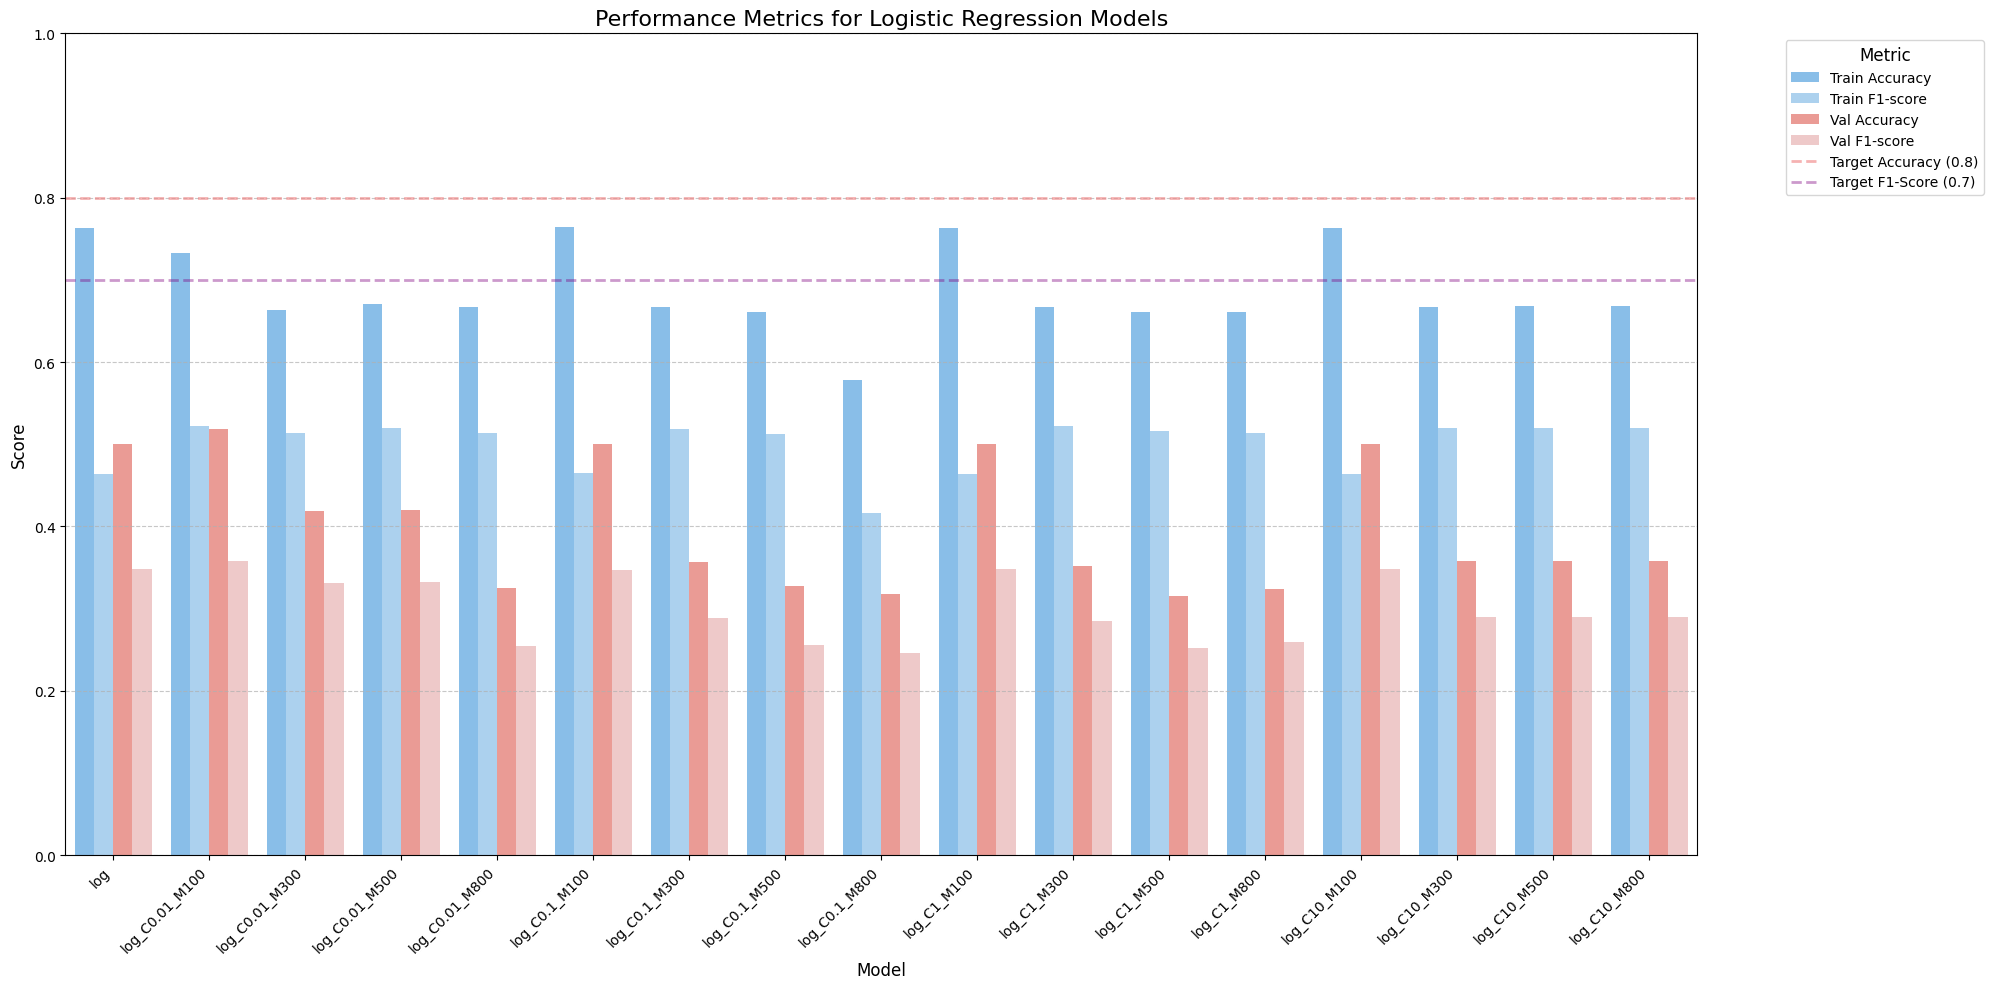

In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score

# List of all Logistic Regression models
logistic_regression_models = [
    log,
    log_c001_m100, log_c001_m300, log_c001_m500, log_c001_m800,
    log_c01_m100, log_c01_m300, log_c01_m500, log_c01_m800,
    log_c1_m100, log_c1_m300, log_c1_m500, log_c1_m800,
    log_c10_m100, log_c10_m300, log_c10_m500, log_c10_m800
]

# Corresponding model names for better readability on the chart
model_names = [
    'log',
    'log_C0.01_M100', 'log_C0.01_M300', 'log_C0.01_M500', 'log_C0.01_M800',
    'log_C0.1_M100', 'log_C0.1_M300', 'log_C0.1_M500', 'log_C0.1_M800',
    'log_C1_M100', 'log_C1_M300', 'log_C1_M500', 'log_C1_M800',
    'log_C10_M100', 'log_C10_M300', 'log_C10_M500', 'log_C10_M800'
]

# Function to collect metrics for each model
def collect_metrics(models, names, X_train, y_train, X_val, y_val):
    metrics_data = []
    for model, name in zip(models, names):
        # Train set predictions and metrics
        y_train_pred = model.predict(X_train)
        train_acc = accuracy_score(y_train, y_train_pred)
        train_f1 = f1_score(y_train, y_train_pred, average='macro')

        # Validation set predictions and metrics
        y_val_pred = model.predict(X_val)
        val_acc = accuracy_score(y_val, y_val_pred)
        val_f1 = f1_score(y_val, y_val_pred, average='macro')

        metrics_data.append({
            'Model': name,
            'Train Accuracy': train_acc,
            'Train F1-score': train_f1,
            'Val Accuracy': val_acc,
            'Val F1-score': val_f1
        })
    return pd.DataFrame(metrics_data)

# Collect metrics for all Logistic Regression models
metrics_df = collect_metrics(logistic_regression_models, model_names, X_train, y_train, X_val, y_val)

# Melt the DataFrame for easier plotting with seaborn
metrics_melted = metrics_df.melt(id_vars=['Model'], var_name='Metric', value_name='Score')


# palette_cb = ['#0072B2', 'plum', 'forestgreen', 'mediumpurple']
palette_cb = ['#2196F3', '#64B5F6', '#F44336', '#EF9A9A']

# Create the bar chart
plt.figure(figsize=(20, 10)) # Increased figure size for better readability
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_melted, palette=palette_cb, alpha=0.6)
plt.title('Performance Metrics for Logistic Regression Models', fontsize=16)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate x-axis labels
plt.yticks(fontsize=10)
plt.ylim(0, 1) # Metrics are between 0 and 1

plt.axhline(0.8, color='lightcoral', linestyle='--', linewidth=2, label=f'Target Accuracy (0.8)', alpha= 0.6)
plt.axhline(0.7, color='purple', linestyle='--', linewidth=2, label=f'Target F1-Score (0.7)', alpha= 0.4)

plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig('logistic_regression_performance.png') # Save the figure
plt.show()

In [129]:
# report of best model on X_val
y_pred = log_c001_m500.predict(X_val)

report = classification_report(y_val, y_pred, output_dict=True)
pd.DataFrame(report).transpose().round(2)

,precision,recall,f1-score,support
Accessories,0.83,0.23,0.36,1620.00
Bikes,0.52,0.74,0.61,915.00
Clothing,0.21,0.43,0.28,323.00
Components,0.04,1.00,0.07,18.00
accuracy,0.42,0.42,0.42,0.42
macro avg,0.40,0.60,0.33,2876.00
weighted avg,0.66,0.42,0.43,2876.00


                                              feature  importance_mean  \
4                                 offline_order_ratio         0.114646   
3                                    avg_order_amount         0.069181   
23                                 spending_group_low         0.057871   
24                              spending_group_median         0.021960   
20                    customer_country_United Kingdom         0.008201   
14                       sales_country_United Kingdom         0.008201   
15                                 sales_group_Europe         0.007406   
21                              customer_group_Europe         0.007406   
16                                sales_group_Pacific         0.004930   
11                            sales_country_Australia         0.004930   
22                             customer_group_Pacific         0.004930   
17                         customer_country_Australia         0.004930   
25                                spen

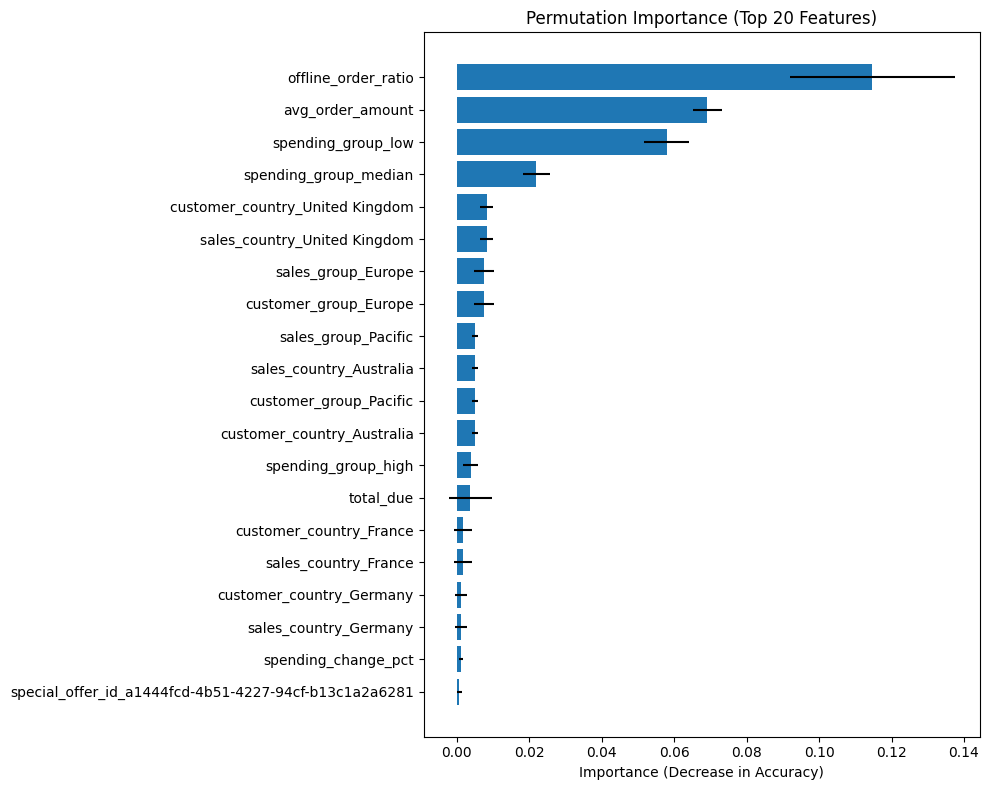

In [130]:
#  do permutation importance on model
result = permutation_importance(
    log_c001_m500,      # the best model
    X_val,             # use validation set to assess the importance
    y_val,
    n_repeats=10,
    random_state=42,
    scoring='recall_macro'   # by recall macro (due to our goal)
)

#  make it as  DataFrame
importance = pd.DataFrame({
    'feature': X_val.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values('importance_mean', ascending=False)

print(importance.head(20))

# graph
plt.figure(figsize=(10, 8))
plt.barh(
    importance['feature'].head(20),
    importance['importance_mean'].head(20),
    xerr=importance['importance_std'].head(20)
)
plt.gca().invert_yaxis()
plt.title("Permutation Importance (Top 20 Features)")
plt.xlabel("Importance (Decrease in Accuracy)")
plt.tight_layout()
plt.show()


**Random Forest**

In [140]:
# esti = 100-500, maxdepth=None, split=2, leaf=1
model_tuning_esti= [
    rf,
    rf_esti100_depthNone_split2_leaf1,
    rf_esti200_depthNone_split2_leaf1,
    rf_esti300_depthNone_split2_leaf1,
    rf_esti400_depthNone_split2_leaf1,
    rf_esti500_depthNone_split2_leaf1
    ]

print_metrice(model_tuning_esti)

The model RandomForestClassifier(class_weight='balanced', random_state=42)'s metrics
Train set:   Accuracy: 0.9978
Train set:   F1-score: 0.9955
Val set:   Accuracy: 0.9047
Val set:   F1-score: 0.7143
--------------------
The model RandomForestClassifier(class_weight='balanced', random_state=42)'s metrics
Train set:   Accuracy: 0.9978
Train set:   F1-score: 0.9955
Val set:   Accuracy: 0.9047
Val set:   F1-score: 0.7143
--------------------
The model RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)'s metrics
Train set:   Accuracy: 0.9978
Train set:   F1-score: 0.9955
Val set:   Accuracy: 0.9047
Val set:   F1-score: 0.7111
--------------------
The model RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)'s metrics
Train set:   Accuracy: 0.9976
Train set:   F1-score: 0.9952
Val set:   Accuracy: 0.9047
Val set:   F1-score: 0.7094
--------------------
The model RandomForestClassifi

In [141]:
# maxdepth=5-30, esti = 100, split=2, leaf=1
model_tuning_max_depth= [
    rf_esti100_depth5_split2_leaf1,
    rf_esti100_depth10_split2_leaf1,
    rf_esti100_depth15_split2_leaf1,   # depth=15
    rf_esti100_depth20_split2_leaf1,
    rf_esti100_depth25_split2_leaf1,
    rf_esti100_depth30_split2_leaf1
    ]

print_metrice(model_tuning_max_depth)

The model RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=42)'s metrics
Train set:   Accuracy: 0.8455
Train set:   F1-score: 0.7099
Val set:   Accuracy: 0.7170
Val set:   F1-score: 0.5748
--------------------
The model RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=42)'s metrics
Train set:   Accuracy: 0.9527
Train set:   F1-score: 0.9390
Val set:   Accuracy: 0.8853
Val set:   F1-score: 0.7154
--------------------
The model RandomForestClassifier(class_weight='balanced', max_depth=15, random_state=42)'s metrics
Train set:   Accuracy: 0.9949
Train set:   F1-score: 0.9935
Val set:   Accuracy: 0.9040
Val set:   F1-score: 0.7246
--------------------
The model RandomForestClassifier(class_weight='balanced', max_depth=20, random_state=42)'s metrics
Train set:   Accuracy: 0.9978
Train set:   F1-score: 0.9955
Val set:   Accuracy: 0.9037
Val set:   F1-score: 0.7208
--------------------
The model RandomForestClassifier(class_weight='balanced',

In [142]:
# split=2,5,10, esti=100,  depth=15, leaf=1
model_tuning_split= [
    rf_esti100_depth15_split2_leaf1,
    rf_esti100_depth15_split5_leaf1,    # split=5
    rf_esti100_depth15_split10_leaf1
    ]

print_metrice(model_tuning_split)

The model RandomForestClassifier(class_weight='balanced', max_depth=15, random_state=42)'s metrics
Train set:   Accuracy: 0.9949
Train set:   F1-score: 0.9935
Val set:   Accuracy: 0.9040
Val set:   F1-score: 0.7246
--------------------
The model RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_split=5, random_state=42)'s metrics
Train set:   Accuracy: 0.9829
Train set:   F1-score: 0.9480
Val set:   Accuracy: 0.8926
Val set:   F1-score: 0.7269
--------------------
The model RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_split=10, random_state=42)'s metrics
Train set:   Accuracy: 0.9657
Train set:   F1-score: 0.8882
Val set:   Accuracy: 0.8814
Val set:   F1-score: 0.7111
--------------------


In [68]:
#  leaf=1-6, esti=100,  depth=15, split=5
model_tuning_leaf= [
    rf_esti100_depth15_split5_leaf1,    # best
    rf_esti100_depth15_split5_leaf2,
    rf_esti100_depth15_split5_leaf4,   # leaf=4
    rf_esti100_depth15_split5_leaf6
    ]

print_metrice(model_tuning_leaf)

The model RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_split=5, random_state=42)'s metrics
Train set:   Accuracy: 0.9829
Train set:   F1-score: 0.9480
Val set:   Accuracy: 0.8926
Val set:   F1-score: 0.7269
--------------------
The model RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=2, min_samples_split=5,
                       random_state=42)'s metrics
Train set:   Accuracy: 0.9726
Train set:   F1-score: 0.9123
Val set:   Accuracy: 0.8912
Val set:   F1-score: 0.7218
--------------------
The model RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=4, min_samples_split=5,
                       random_state=42)'s metrics
Train set:   Accuracy: 0.9510
Train set:   F1-score: 0.8522
Val set:   Accuracy: 0.8710
Val set:   F1-score: 0.6966
--------------------
The model RandomForestClassifier(class_weight='balanced', max_depth=15,
  

In [144]:
# esti=100-500, depth=15, splt=5, leaf=4
model_tuning_leaf= [
    rf_esti100_depth15_split5_leaf4,
    rf_esti300_depth15_split5_leaf4,
    rf_esti500_depth15_split5_leaf4
    ]

print_metrice(model_tuning_leaf)

The model RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=4, min_samples_split=5,
                       random_state=42)'s metrics
Train set:   Accuracy: 0.9510
Train set:   F1-score: 0.8522
Val set:   Accuracy: 0.8710
Val set:   F1-score: 0.6966
--------------------
The model RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=4, min_samples_split=5,
                       n_estimators=300, random_state=42)'s metrics
Train set:   Accuracy: 0.9504
Train set:   F1-score: 0.8511
Val set:   Accuracy: 0.8713
Val set:   F1-score: 0.6958
--------------------
The model RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=4, min_samples_split=5,
                       n_estimators=500, random_state=42)'s metrics
Train set:   Accuracy: 0.9515
Train set:   F1-score: 0.8545
Val set:   Accuracy: 0.8790
Val set:   F1-score: 0.7029
----------------

In [145]:
# report of best model on X_train
y_pred = rf_esti100_depth15_split5_leaf1.predict(X_train)

report = classification_report(y_train, y_pred, output_dict=True)
pd.DataFrame(report).transpose().round(2)

,precision,recall,f1-score,support
Accessories,0.98,0.99,0.98,2635.00
Bikes,1.00,0.98,0.99,3507.00
Clothing,0.93,1.00,0.96,486.00
Components,0.75,1.00,0.86,46.00
accuracy,0.98,0.98,0.98,0.98
macro avg,0.92,0.99,0.95,6674.00
weighted avg,0.98,0.98,0.98,6674.00


In [146]:
# report of best model on X_val
y_pred = rf_esti100_depth15_split5_leaf1.predict(X_val)

report = classification_report(y_val, y_pred, output_dict=True)
pd.DataFrame(report).transpose().round(2)

,precision,recall,f1-score,support
Accessories,0.92,0.94,0.93,1620.00
Bikes,0.97,0.88,0.92,915.00
Clothing,0.67,0.72,0.70,323.00
Components,0.26,0.61,0.36,18.00
accuracy,0.89,0.89,0.89,0.89
macro avg,0.70,0.79,0.73,2876.00
weighted avg,0.90,0.89,0.90,2876.00


In [147]:
# SMOTE data
y_pred = SMOTE_rf_esti100_depth15_split5_leaf1.predict(X_val)

report = classification_report(y_val, y_pred, output_dict=True)
pd.DataFrame(report).transpose().round(2)

# compare the best data, model trained by SMOTE data does not show a better performance

,precision,recall,f1-score,support
Accessories,0.92,0.92,0.92,1620.00
Bikes,0.96,0.88,0.92,915.00
Clothing,0.63,0.71,0.67,323.00
Components,0.24,0.61,0.34,18.00
accuracy,0.88,0.88,0.88,0.88
macro avg,0.69,0.78,0.71,2876.00
weighted avg,0.90,0.88,0.89,2876.00


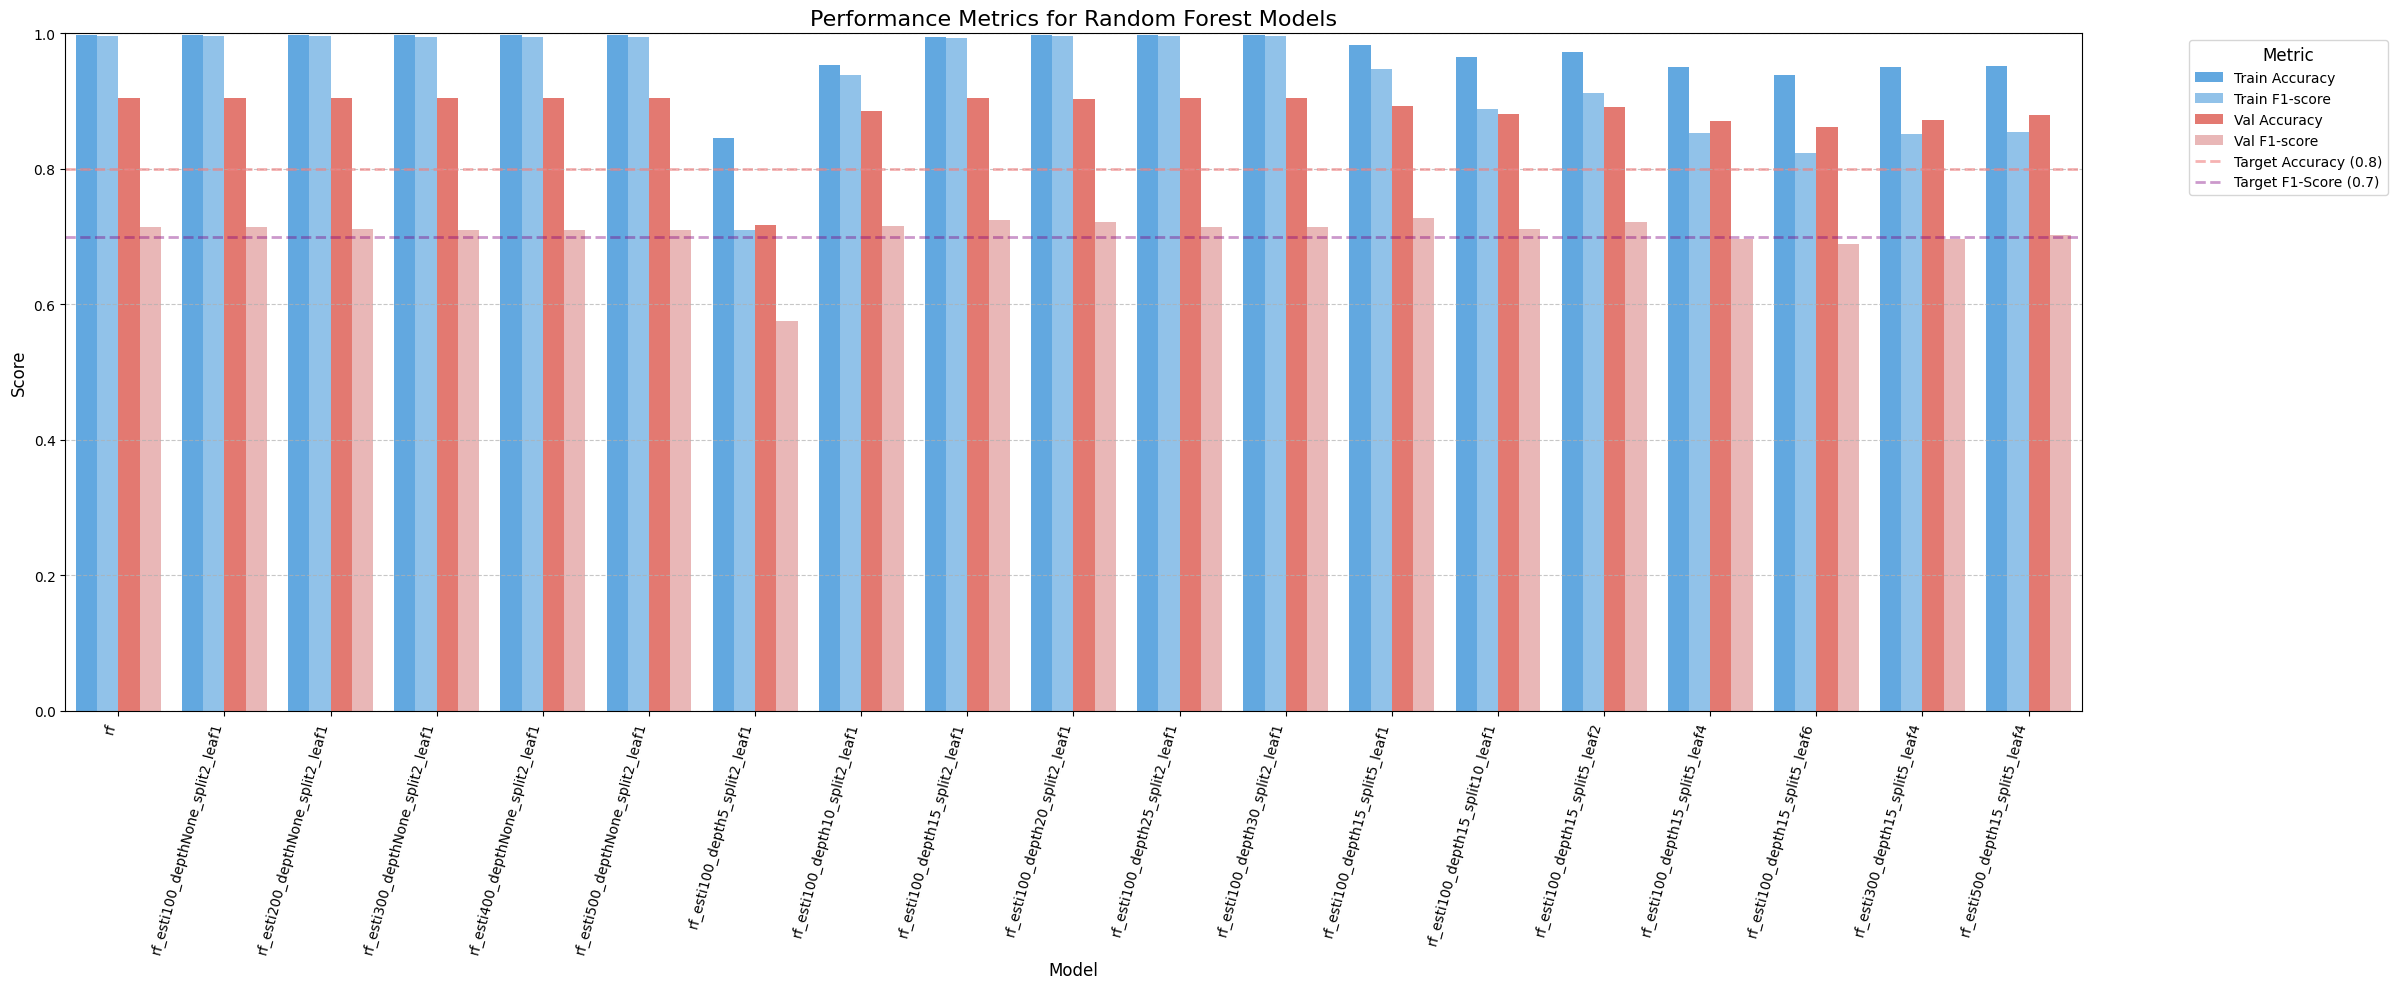

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score

# List of all Random Forest models
random_forest_models = [
rf,
rf_esti100_depthNone_split2_leaf1,
rf_esti200_depthNone_split2_leaf1,
rf_esti300_depthNone_split2_leaf1,
rf_esti400_depthNone_split2_leaf1,
rf_esti500_depthNone_split2_leaf1,

rf_esti100_depth5_split2_leaf1,
rf_esti100_depth10_split2_leaf1,
rf_esti100_depth15_split2_leaf1,
rf_esti100_depth20_split2_leaf1,
rf_esti100_depth25_split2_leaf1,
rf_esti100_depth30_split2_leaf1,

rf_esti100_depth15_split2_leaf1,
rf_esti100_depth15_split5_leaf1,
rf_esti100_depth15_split10_leaf1,

rf_esti100_depth15_split5_leaf1,
rf_esti100_depth15_split5_leaf2,
rf_esti100_depth15_split5_leaf4,
rf_esti100_depth15_split5_leaf6,

rf_esti100_depth15_split5_leaf4,
rf_esti300_depth15_split5_leaf4,
rf_esti500_depth15_split5_leaf4

]

# Corresponding model names for better readability on the chart
rf_model_names = [
'rf',
'rf_esti100_depthNone_split2_leaf1',
'rf_esti200_depthNone_split2_leaf1',
'rf_esti300_depthNone_split2_leaf1',
'rf_esti400_depthNone_split2_leaf1',
'rf_esti500_depthNone_split2_leaf1',

'rf_esti100_depth5_split2_leaf1',
'rf_esti100_depth10_split2_leaf1',
'rf_esti100_depth15_split2_leaf1',
'rf_esti100_depth20_split2_leaf1',
'rf_esti100_depth25_split2_leaf1',
'rf_esti100_depth30_split2_leaf1',

'rf_esti100_depth15_split2_leaf1',
'rf_esti100_depth15_split5_leaf1',
'rf_esti100_depth15_split10_leaf1',

'rf_esti100_depth15_split5_leaf1',
'rf_esti100_depth15_split5_leaf2',
'rf_esti100_depth15_split5_leaf4',
'rf_esti100_depth15_split5_leaf6',

'rf_esti100_depth15_split5_leaf4',
'rf_esti300_depth15_split5_leaf4',
'rf_esti500_depth15_split5_leaf4'
]

# Function to collect metrics for each model (re-defined or ensured to be available)
def collect_metrics(models, names, X_train, y_train, X_val, y_val):
    metrics_data = []
    for model, name in zip(models, names):
        # Train set predictions and metrics
        y_train_pred = model.predict(X_train)
        train_acc = accuracy_score(y_train, y_train_pred)
        train_f1 = f1_score(y_train, y_train_pred, average='macro')

        # Validation set predictions and metrics
        y_val_pred = model.predict(X_val)
        val_acc = accuracy_score(y_val, y_val_pred)
        val_f1 = f1_score(y_val, y_val_pred, average='macro')

        metrics_data.append({
            'Model': name,
            'Train Accuracy': train_acc,
            'Train F1-score': train_f1,
            'Val Accuracy': val_acc,
            'Val F1-score': val_f1
        })
    return pd.DataFrame(metrics_data)

# Collect metrics for all Random Forest models
rf_metrics_df = collect_metrics(random_forest_models, rf_model_names, X_train, y_train, X_val, y_val)

# Melt the DataFrame for easier plotting with seaborn
rf_metrics_melted = rf_metrics_df.melt(id_vars=['Model'], var_name='Metric', value_name='Score')

# Create the bar chart
plt.figure(figsize=(24, 10)) # Increased figure size for better readability and more models
sns.barplot(x='Model', y='Score', hue='Metric', data=rf_metrics_melted, palette=palette_cb, alpha=0.8)
plt.title('Performance Metrics for Random Forest Models', fontsize=16)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=75, ha='right', fontsize=10) # Rotate x-axis labels more for long names
plt.yticks(fontsize=10)
plt.ylim(0, 1) # Metrics are between 0 and 1

plt.axhline(0.8, color='lightcoral', linestyle='--', linewidth=2, label='Target Accuracy (0.8)', alpha=0.6)
plt.axhline(0.7, color='purple', linestyle='--', linewidth=2, label='Target F1-Score (0.7)', alpha=0.4)

plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig('random_forest_performance.png', dpi=300) # Save the figure with higher resolution
plt.show()

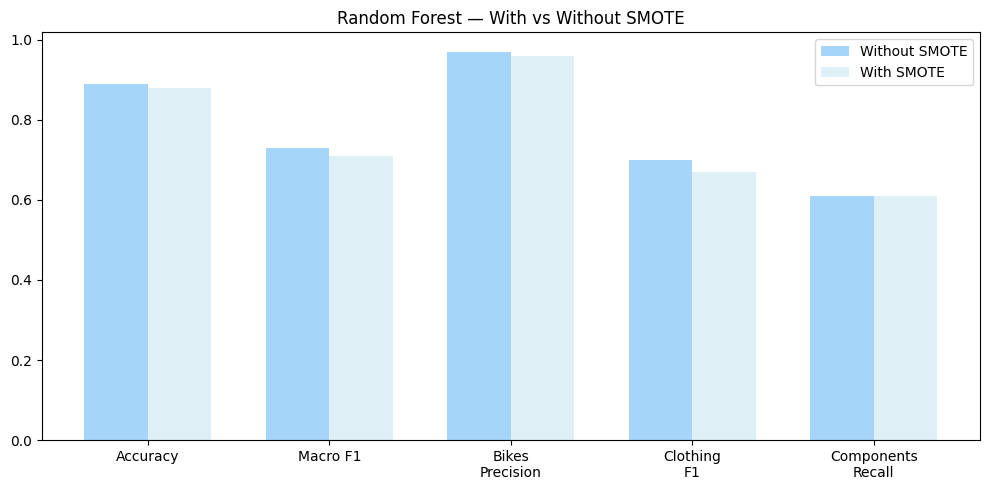

In [174]:
import numpy as np

metrics = ['Accuracy', 'Macro F1', 'Bikes\nPrecision', 'Clothing\nF1', 'Components\nRecall']
without_smote = [0.89, 0.73, 0.97, 0.70, 0.61]
with_smote =    [0.88, 0.71, 0.96, 0.67, 0.61]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, without_smote, width, label='Without SMOTE', color='#2196F3', alpha=0.4)
ax.bar(x + width/2, with_smote,    width, label='With SMOTE',    color='lightblue', alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_title('Random Forest — With vs Without SMOTE')
plt.tight_layout()
plt.savefig('smote and no smote',dpi=300)
plt.show()

In [ ]:
# feature importance

                                              feature  importance_mean  \
2                                 avg_items_per_order         0.267894   
4                                 offline_order_ratio         0.161457   
3                                    avg_order_amount         0.119674   
0                                           total_due         0.049884   
1                                 spending_change_pct         0.029010   
20                    customer_country_United Kingdom         0.009597   
23                                 spending_group_low         0.007586   
14                       sales_country_United Kingdom         0.006603   
7   special_offer_id_a1444fcd-4b51-4227-94cf-b13c1...         0.005593   
15                                 sales_group_Europe         0.004392   
10  special_offer_id_df7c9acd-bc0c-4ab0-93ec-064e2...         0.004287   
17                         customer_country_Australia         0.003994   
22                             custome

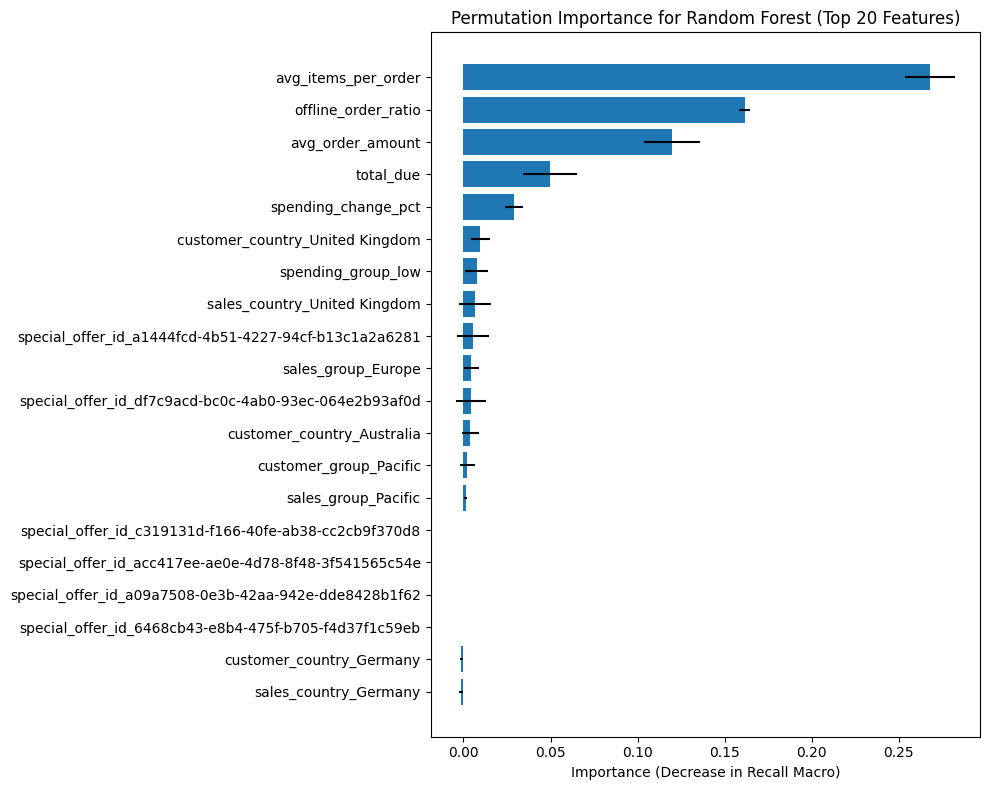

In [69]:
result = permutation_importance(
    rf_esti100_depth15_split5_leaf1,      # the best model
    X_val,             # use validation set to assess the importance
    y_val,
    n_repeats=10,
    random_state=42,
    scoring='recall_macro'   # by recall macro (due to our goal)
)

#  make it as  DataFrame
importance = pd.DataFrame({
    'feature': X_val.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values('importance_mean', ascending=False)

print(importance.head(20))

# graph
plt.figure(figsize=(10, 8))
plt.barh(
    importance['feature'].head(20),
    importance['importance_mean'].head(20),
    xerr=importance['importance_std'].head(20)
)
plt.gca().invert_yaxis()
plt.title("Permutation Importance for Random Forest (Top 20 Features)")
plt.xlabel("Importance (Decrease in Recall Macro)")
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=300)
plt.show()

**XGBoost**

In [149]:
# XGBoost
print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

best_xgb = grid.best_estimator_

# already trained, just predict
y_train_pred = best_xgb.predict(X_train)
y_val_pred   = best_xgb.predict(X_val)

# evaluate
print(f'Train Accuracy: {accuracy_score(y_train_enc, y_train_pred):.4f}')
print(f'Train F1:       {f1_score(y_train_enc, y_train_pred, average="macro"):.4f}')
print()
print(f'Val Accuracy:   {accuracy_score(y_val_enc, y_val_pred):.4f}')
print(f'Val F1:         {f1_score(y_val_enc, y_val_pred, average="macro"):.4f}')


Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300, 'subsample': 1.0}
Best score: 0.7985303879970124
Train Accuracy: 0.9690
Train F1:       0.9590

Val Accuracy:   0.9145
Val F1:         0.7496


In [150]:
# classification report
report = classification_report(y_train_enc, y_train_pred, target_names=le.classes_, output_dict=True)
pd.DataFrame(report).transpose().round(2)

,precision,recall,f1-score,support
Accessories,0.95,0.98,0.96,2635.00
Bikes,0.99,0.98,0.99,3507.00
Clothing,0.90,0.87,0.89,486.00
Components,1.00,1.00,1.00,46.00
accuracy,0.97,0.97,0.97,0.97
macro avg,0.96,0.96,0.96,6674.00
weighted avg,0.97,0.97,0.97,6674.00


In [151]:
# classification report
report = classification_report(y_val_enc, y_val_pred, target_names=le.classes_, output_dict=True)
pd.DataFrame(report).transpose().round(2)

,precision,recall,f1-score,support
Accessories,0.94,0.96,0.95,1620.00
Bikes,0.92,0.92,0.92,915.00
Clothing,0.81,0.71,0.76,323.00
Components,0.32,0.44,0.37,18.00
accuracy,0.91,0.91,0.91,0.91
macro avg,0.75,0.76,0.75,2876.00
weighted avg,0.91,0.91,0.91,2876.00


**Graphs**

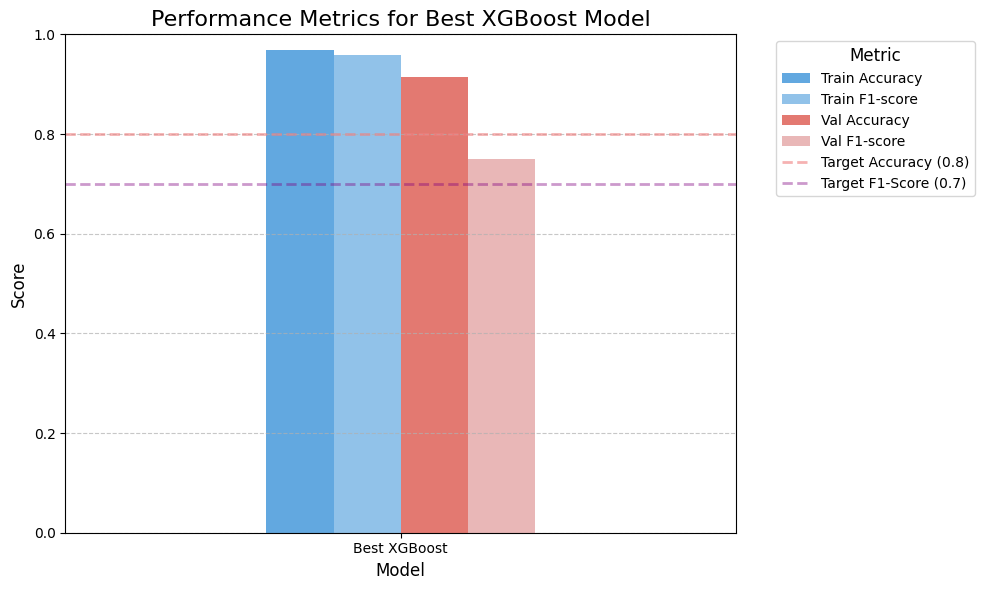

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

# Calculate metrics for the best XGBoost model
train_acc = accuracy_score(y_train_enc, y_train_pred)
train_f1 = f1_score(y_train_enc, y_train_pred, average='macro')

val_acc = accuracy_score(y_val_enc, y_val_pred)
val_f1 = f1_score(y_val_enc, y_val_pred, average='macro')

# Create a DataFrame for the metrics
metrics_data = [{
    'Model': 'Best XGBoost',
    'Train Accuracy': train_acc,
    'Train F1-score': train_f1,
    'Val Accuracy': val_acc,
    'Val F1-score': val_f1
}]

metrics_df = pd.DataFrame(metrics_data)

# Melt the DataFrame for easier plotting with seaborn
metrics_melted = metrics_df.melt(id_vars=['Model'], var_name='Metric', value_name='Score')

# Define a color palette
palette_cb = ['#2196F3', '#64B5F6', '#F44336', '#EF9A9A']

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_melted, palette=palette_cb, alpha=0.8, width= 0.4)
plt.title('Performance Metrics for Best XGBoost Model', fontsize=16)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=0, ha='center', fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 1) # Metrics are between 0 and 1

plt.axhline(0.8, color='lightcoral', linestyle='--', linewidth=2, label='Target Accuracy (0.8)', alpha=0.6)
plt.axhline(0.7, color='purple', linestyle='--', linewidth=2, label='Target F1-Score (0.7)', alpha=0.4)

plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig('xgboost_performance.png', dpi=300) # Save the figure with higher resolution
plt.show()

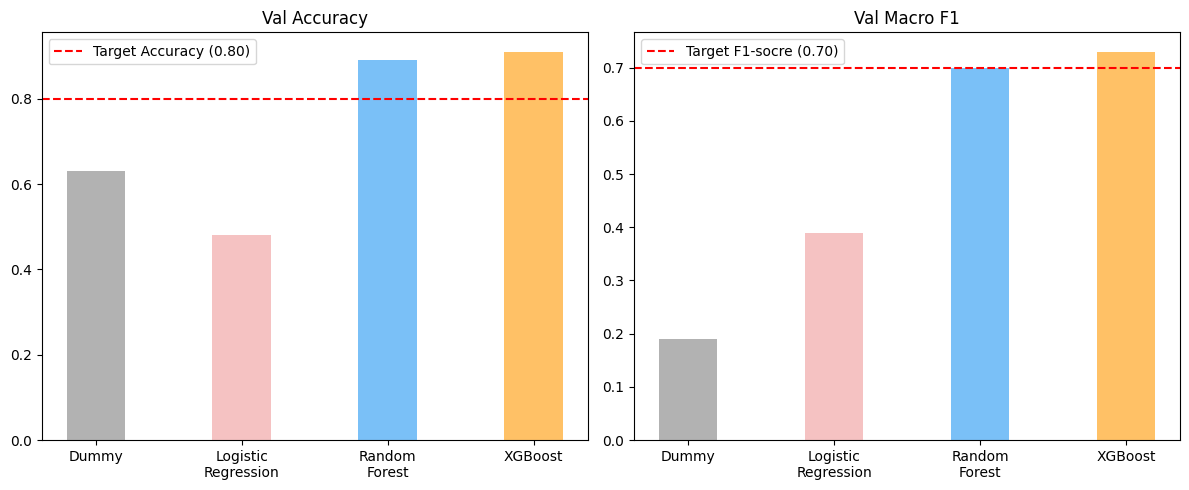

In [165]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = ['Dummy', 'Logistic\nRegression', 'Random\nForest', 'XGBoost']
accuracy = [0.63, 0.48, 0.89, 0.91]
f1 = [0.19, 0.39, 0.70, 0.73]

color=['gray', '#EF9A9A', '#2196F3', '#FF9800']


axes[0].bar(models, accuracy, color=color, width=0.4, alpha=0.6)
axes[0].axhline(y=0.80, color='red', linestyle='--', label='Target Accuracy (0.80)')
axes[0].set_title('Val Accuracy')
axes[0].legend()

axes[1].bar(models, f1, color=['gray', '#EF9A9A', '#2196F3', '#FF9800'], width=0.4,  alpha=0.6)
axes[1].axhline(y=0.70, color='red', linestyle='--', label='Target F1-socre (0.70)')
axes[1].set_title('Val Macro F1')
axes[1].legend()

plt.tight_layout()
plt.savefig('Val Comparison.png', dpi=300)
plt.show()

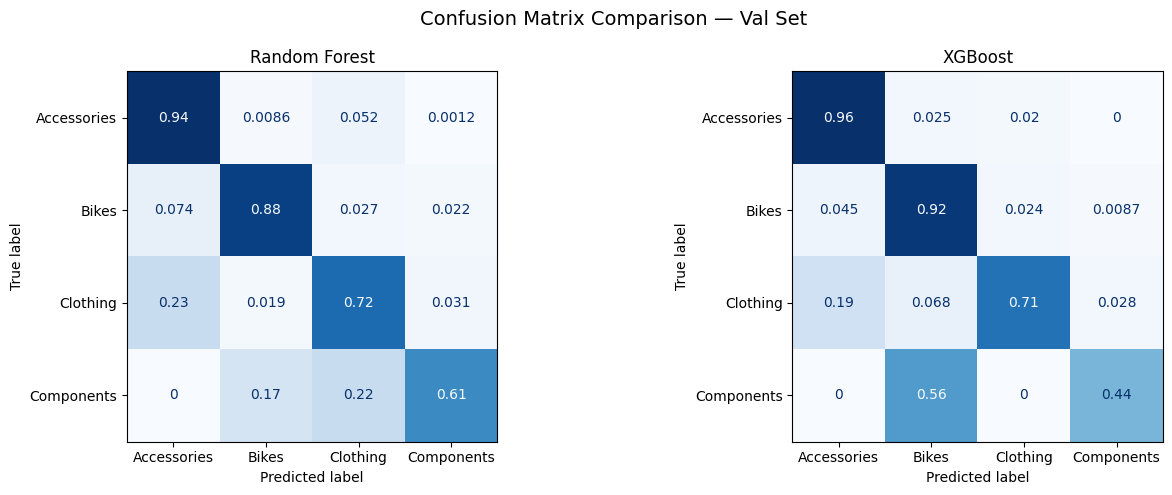

In [166]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
y_pred_rf = rf_esti100_depth15_split5_leaf1.predict(X_val)
cm_rf = confusion_matrix(y_val, y_pred_rf, normalize='true')
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                                  display_labels=y_val.unique())
disp_rf.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Random Forest')

# XGBoost
cm_xgb = confusion_matrix(y_val_enc, y_val_pred, normalize='true')
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb,
                                   display_labels=le.classes_)
disp_xgb.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('XGBoost')

plt.suptitle('Confusion Matrix Comparison — Val Set', fontsize=14)
plt.tight_layout()
plt.savefig('Confusion matrics.png', dpi=300)
plt.show()

In [155]:
model_performance_explanations = """
From numerous experiments across three algorithms, Logistic Regression achieved the lowest performance,
with around 0.3~0.5 accuracy and F1-score under various hyperparameter tuning configurations,
indicating that no linear relationship exists in this case and therefore Logistic Regression cannot capture the pattern effectively.

For Random Forest, the model (n_estimators=100, max_depth=15, min_samples_split=5, min_samples_leaf=1)
is selected over other configurations with slightly higher scores,
achieving accuracy of 0.98 (train) and 0.89 (val), and F1-score of 0.95 (train) and 0.73 (val),
indicating significant overfitting.

In terms of XGBoost,
GridSearchCV was applied to find the best hyperparameters using macro F1-score on the val set as the evaluation standard (due to multi-class classification).
The performance is slightly higher than Random Forest, with accuracy of 0.96 (train) and 0.91 (val),
and F1-score of 0.95 (train) and 0.73 (val),
indicating that the model also overfits but less severely than Random Forest.

Looking at the confusion matrices of the two best models on the val set,
although Components has only 18 samples, Random Forest demonstrates 0.32 precision and 0.44 recall,
while XGBoost shows 0.31 precision and 0.28 recall.
Furthermore, the precision of each class from Accessories to Components is 0.92, 0.96, 0.68 and 0.32 for Random Forest,
and 0.93, 0.93, 0.79 and 0.31 for XGBoost.

These findings reveal that XGBoost achieves slightly higher scores on most majority classes,
while Random Forest demonstrates better performance on minority classes.

SMOTE was applied exclusively to Random Forest to address class imbalance,
however the resulting confusion matrix clearly shows that this method substantially decreases the precision of minority classes,
such as Clothing (from 0.85 to 0.75) and Components (from 0.18 to 0.07),
suggesting that SMOTE is not the most effective approach in this case.
"""

In [156]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [144]:
# DO NOT MODIFY THE CODE IN THIS CELL
# Load datasets
try:
  customer_df = pd.read_csv(at.folder_path / "customer.csv")
  person_df = pd.read_csv(at.folder_path / "person.csv")
  product_category_df = pd.read_csv(at.folder_path / "product_category.csv")
  product_cost_history_df = pd.read_csv(at.folder_path / "product_cost_history.csv")
  product_list_price_history_df = pd.read_csv(at.folder_path / "product_list_price_history.csv")
  product_sub_category_df = pd.read_csv(at.folder_path / "product_sub_category.csv")
  product_df = pd.read_csv(at.folder_path / "product.csv")
  sales_order_detail_df = pd.read_csv(at.folder_path / "sales_order_detail.csv")
  sales_order_header_df = pd.read_csv(at.folder_path / "sales_order_header.csv")
  sales_territory_df = pd.read_csv(at.folder_path / "sales_territory.csv")
  special_offer_product_df = pd.read_csv(at.folder_path / "special_offer_product.csv")
  special_offer_df = pd.read_csv(at.folder_path / "special_offer.csv")
  store_df = pd.read_csv(at.folder_path / "store.csv")
  unit_measure_df = pd.read_csv(at.folder_path / "unit_measure.csv")
except Exception as e:
  print(e)

In [145]:
# keep only sold products
sold_product_ids = sales_order_detail_df['product_id'].unique()  # select sold product_id

product_df = product_df[product_df['product_id'].isin(sold_product_ids)].drop_duplicates()  # remove id not in sold product_id

product_list_price_history_df = product_list_price_history_df[
    product_list_price_history_df['product_id'].isin(sold_product_ids)
].drop_duplicates()

product_cost_history_df = product_cost_history_df[
    product_cost_history_df['product_id'].isin(sold_product_ids)
].drop_duplicates()

product_category_df = product_category_df.drop_duplicates()   # remove duplicate

# 2. merge, and compute profit
profit_table = (
    product_list_price_history_df[['product_id', 'list_price']]
    .merge(product_cost_history_df[['product_id', 'standard_cost']], on='product_id', how='left')
)

profit_table['profit'] = profit_table['list_price'] - profit_table['standard_cost']  # compute

# 3. merge category info
profit_table = (
    profit_table
    .merge(product_df[['product_id', 'product_subcategory_id']], on='product_id', how='left')
    .merge(product_sub_category_df[['product_subcategory_id', 'product_category_id']], on='product_subcategory_id', how='left')
    .merge(product_category_df, on='product_category_id', how='left')
)

# 4. keep only needed columns
profit_table = profit_table[['name', 'profit']]

# 5. compute category average profit
profit_table['category_avg_profit'] = profit_table.groupby('name')['profit'].transform('mean')

# separate summary table
category_avg_profit = (
    profit_table.groupby('name')['profit']
    .mean()
    .reset_index()
    .rename(columns={'profit': 'category_avg_profit'})
)


In [146]:
category_avg_profit

,name,category_avg_profit
0,Accessories,21.431486
1,Bikes,602.122889
2,Clothing,18.548101
3,Components,276.810942


In [ ]:
business_impacts_explanations = """
To match the business objective (increasing profit through targeted advertising on each customer segment),
rf_esti100_depth15_split5_leaf1 is selected over other models.

Given that Bikes generates the highest average profit ($602 per transaction),
maximizing precision for this class minimizes wasted advertising spend on non-Bikes customers,
delivering greater business value despite marginally lower overall accuracy.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [ ]:
experiment_outcome = "Hypothesis Confirmed"

In [ ]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [ ]:
experiment_results_explanations = """

New insights:
1. Bikes customers are a minority but generate the highest profit.
2. SMOTE cannot handle imbalanced data in this case well.

As of now, this model successfully achieves high precision in predicting Bikes customers to increase revenue,
so no further experiments are required currently.
However, customer behavior patterns should be tracked regularly to prevent data drift or concept drift.

Potential next steps:
1. Collect more order history data to strengthen the model and make it more reliable and robust.
2. Create additional features through feature engineering, allowing the model to learn patterns more easily.
3. Increase the precision of Components and Clothing (optional, as the current model already contributes sufficient profit).

Due to the high precision and recall of majority classes, especially in the high-profit Bikes category,
this model is recommended for real-world deployment.

Recommended deployment steps (technical):
1. Save the model as a file (e.g. pickle or joblib)
2. Build a simple API or interface (e.g. Streamlit, Flask)
3. Integrate with the company's CRM or marketing system
4. Done!

Recommended maintenance steps:
1. Monitor model performance regularly
2. Retrain the model with new data (every 3~6 months at least),
    especially when new products are launched or old products discontinued
3. Take company pricing and marketing strategies into consideration,
   e.g. "Clothing may become the most profitable category after re-pricing"
4. Done!

"""

In [ ]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)